# Load data

In [ ]:
import pickle
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)
# Load and prepare data
train_data = load_pickle("../data/train.pickel")
test_data = load_pickle("../data/test.pickle")


In [1]:
from typing import List, Tuple
import numpy as np

def label_to_tuple(label: int) -> Tuple[bool, bool, bool, bool]:
    '''
    Convert a class label to a 4d vector binary encoding the brake status.
    Input: class label (0-11).
    Output: (front_left, front_right, rear_left, rear_right), where True indicates an irregularity.
    '''
    match label:
        case 0: return (False, False, False, False)
        case 1: return (False, False, True, False)
        case 2: return (False, False, False, True)
        case 3: return (False, False, True, True)
        case 4: return (True, False, False, False)
        case 5: return (False, True, False, False)
        case 6: return (True, True, False, False)
        case 7: return (True, False, True, False)
        case 8: return (False, True, False, True)
        case 9: return (True, False, False, True)
        case 10: return (False, True, True, False)
        case 11: return (True, True, True, True)
    raise ValueError(f"Invalid label: {label}. Expected a value between 0 and 11.")

def tuple_to_label(tup: Tuple[bool, bool, bool, bool]) -> int:
    '''
    Convert a 4d tuple binary encoding the brake status to a class label.
    Input: (front_left, front_right, rear_left, rear_right), where True indicates an irregularity.
    Output: class label (0-11).
    '''
    match tup:
        case (False, False, False, False): return 0
        case (False, False, True, False): return 1
        case (False, False, False, True): return 2
        case (False, False, True, True): return 3
        case (True, False, False, False): return 4
        case (False, True, False, False): return 5
        case (True, True, False, False): return 6
        case (True, False, True, False): return 7
        case (False, True, False, True): return 8
        case (True, False, False, True): return 9
        case (False, True, True, False): return 10
        case (True, True, True, True): return 11
    raise ValueError(f"Invalid tuple: {tup}. Expected a tuple of 4 booleans.")

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score
import random
import pickle
import pandas as pd

In [3]:
import torch, numpy as np, random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [ ]:
# def load_pickle(path):
#     with open(path, 'rb') as f:
#         return pickle.load(f)
#
# train_data = load_pickle("C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/train.pickle")
# test_data = load_pickle("C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/test.pickle")
train_data = train_data.drop(columns=["model"])
test_data = test_data.drop(columns=["model"])
X_train = train_data.drop(columns=["label"])
y_train = train_data["label"]

X_test = test_data.drop(columns=["label"])
y_test = test_data["label"]

y_test = test_data["label"]
# Convert the Series of arrays into a single stacked NumPy array
X_train_sensor = np.stack(X_train["sensor_data"].values)
X_test_sensor = np.stack(X_test["sensor_data"].values)
# Drop sensor_data from tabular features
X_train_tab = X_train.drop(columns=["sensor_data"])
X_test_tab = X_test.drop(columns=["sensor_data"])

C:\Users\anuhe\AppData\Local\Temp\ipykernel_6140\3670925099.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)
C:\Users\anuhe\AppData\Local\Temp\ipykernel_6140\3670925099.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functio

In [5]:
#  Use it to transform the y_train and y_test labels
y_train_multi = y_train.apply(label_to_tuple)
y_test_multi = y_test.apply(label_to_tuple)

# Convert to a DataFrame with separate columns for each brake
y_train_multi_df = pd.DataFrame(y_train_multi.tolist(), columns=["front_left", "front_right", "rear_left", "rear_right"])
y_test_multi_df = pd.DataFrame(y_test_multi.tolist(), columns=["front_left", "front_right", "rear_left", "rear_right"])




In [6]:
y_train_multi_df.shape
y_train_multi_df.head


<bound method NDFrame.head of       front_left  front_right  rear_left  rear_right
0          False        False       True        True
1          False        False       True        True
2          False        False       True        True
3          False        False       True        True
4          False        False       True        True
...          ...          ...        ...         ...
4048        True        False      False       False
4049        True        False      False       False
4050        True        False      False       False
4051        True        False      False       False
4052        True        False      False       False

[4053 rows x 4 columns]>

In [7]:
# Compute mean mass from training data
mass_mean = X_train_tab["mass"].mean()

# Fill missing values in test data using training mean
X_test_tab["mass"] = X_test_tab["mass"].fillna(mass_mean)



           velocity          mass  deceleration_average
count  4.053000e+03  4.053000e+03          4.053000e+03
mean  -1.039605e-15 -5.049008e-16         -3.155630e-16
std    1.000123e+00  1.000123e+00          1.000123e+00
min   -1.344505e+01 -7.759426e-01         -3.487379e+00
25%   -4.975778e-04 -7.759426e-01         -6.693355e-01
50%   -4.975778e-04 -7.759426e-01          1.530402e-02
75%   -4.975778e-04  1.391196e+00          6.317576e-01
max    2.688413e+00  1.391196e+00          8.531451e+00


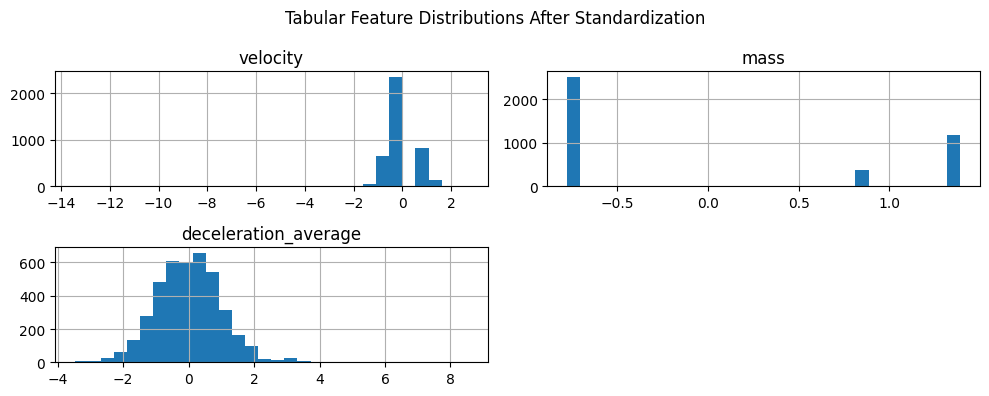

                ch_0           ch_1           ch_2           ch_3  \
count  518784.000000  518784.000000  518784.000000  518784.000000   
mean       -2.845372      -0.049401      -0.057974       0.058683   
std         3.218611       0.220883       0.281784       0.602134   
min        -9.073015      -2.902576      -1.513791      -8.808855   
25%        -5.852964      -0.091153      -0.203334      -0.167592   
50%        -3.733623      -0.019970      -0.087250       0.062211   
75%         0.246481       0.034066       0.080277       0.313486   
max         4.026857       1.281295       1.551846       8.904726   

                ch_4           ch_5  
count  518784.000000  518784.000000  
mean       -0.496792       0.050886  
std         1.812958       0.609783  
min       -12.567163     -19.915649  
25%        -0.959577      -0.184132  
50%        -0.180006       0.052122  
75%         0.356620       0.283430  
max         7.799918       3.573697  


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_tab_scaled = scaler.fit_transform(X_train_tab)
X_test_tab_scaled = scaler.transform(X_test_tab)
import pandas as pd

tab_df = pd.DataFrame(X_train_tab_scaled, columns=X_train_tab.columns)
print(tab_df.describe())
import matplotlib.pyplot as plt

tab_df.hist(bins=30, figsize=(10, 4))
plt.suptitle("Tabular Feature Distributions After Standardization")
plt.tight_layout()
plt.show()
flat = X_train_sensor.reshape(-1, X_train_sensor.shape[2])  # (4053 * 128, 6)

import pandas as pd
sensor_df = pd.DataFrame(flat, columns=[f"ch_{i}" for i in range(6)])
print(sensor_df.describe())
from sklearn.preprocessing import RobustScaler
import numpy as np

# Flatten sensor data
flat_train = X_train_sensor.reshape(-1, 6)
flat_test = X_test_sensor.reshape(-1, 6)

# Fit robust scaler on training data only
scaler = RobustScaler()
flat_train_scaled = scaler.fit_transform(flat_train)
flat_test_scaled = scaler.transform(flat_test)

# Reshape back to original
X_train_sensor_scaled = flat_train_scaled.reshape(X_train_sensor.shape)
X_test_sensor_scaled = flat_test_scaled.reshape(X_test_sensor.shape)

# Clip extreme values to range [-5, 5]
X_train_sensor_clipped = np.clip(X_train_sensor_scaled, -5, 5)
X_test_sensor_clipped = np.clip(X_test_sensor_scaled, -5, 5)

In [9]:
from torch.utils.data import Dataset
import torch

class BrakeDataset(Dataset):
    def __init__(self, sensor_data, tabular_data, labels):
        self.sensor_data = torch.tensor(sensor_data, dtype=torch.float32)
        self.tabular_data = torch.tensor(tabular_data, dtype=torch.float32)
        self.labels = torch.tensor(labels.values, dtype=torch.float32)

    def __len__(self):
        return len(self.sensor_data)

    def __getitem__(self, idx):
        return {
            "sensor": self.sensor_data[idx],   # shape: [seq_len, feature_dim]
            "tabular": self.tabular_data[idx], # shape: [num_tab_features]
            "label": self.labels[idx]          # shape: [4]
        }


In [10]:
from torch.utils.data import DataLoader

train_dataset = BrakeDataset(X_train_sensor_clipped, X_train_tab_scaled, y_train_multi_df)
test_dataset = BrakeDataset(X_test_sensor_clipped, X_test_tab_scaled, y_test_multi_df)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


# Model architecture

In [ ]:
No, the above cell (CELL INDEX: 13) and the below cell (CELL INDEX: 16) are not exactly the same, although they share similar structure and purpose. Here are the key differences:

- **Model Architecture:**  
    - CELL 16 adds dropout and bidirectional options to the LSTM and tabular layers, making the model more flexible and robust.
    - CELL 13 uses a simpler model without dropout or bidirectional LSTM.

- **Training Function:**  
    - CELL 16 includes early stopping based on validation F1 score (`patience` parameter).
    - CELL 16 allows for more hyperparameters to be tuned (dropout, bidirectional).
    - CELL 16 tracks and prints more detailed training progress.

- **Other Differences:**  
    - CELL 16 uses a more modular and extensible code style (e.g., `nn.Sequential` for layers).
    - CELL 16 is more robust for experimentation and model selection.

**Summary:**  
Both cells implement a random search cross-validation for a multi-label LSTM model, but CELL 16 is an improved, more flexible, and robust version compared to CELL 13.

In [1]:
import os
import pickle
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ----------------------------
# Dataset
# ----------------------------
class BrakeDataset(Dataset):
    def __init__(self, sensor_data, tabular_data, labels):
        self.sensor_data = torch.tensor(sensor_data, dtype=torch.float32)
        self.tabular_data = torch.tensor(tabular_data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sensor_data[idx], self.tabular_data[idx], self.labels[idx]

# ----------------------------
# Model
# ----------------------------
class BrakeLSTMModel(nn.Module):
    def __init__(self, tabular_input_dim, lstm_hidden, tabular_hidden, combined_hidden,
                 dropout=0.3, bidirectional=True):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=6,
            hidden_size=lstm_hidden,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if bidirectional or lstm_hidden > 1 else 0
        )
        lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)

        self.tab_fc = nn.Sequential(
            nn.Linear(tabular_input_dim, tabular_hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.fc1 = nn.Sequential(
            nn.Linear(lstm_out_dim + tabular_hidden, combined_hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.fc_out = nn.Linear(combined_hidden, 4)  # 4 labels for multi-label classification

    def forward(self, sensor_seq, tabular_data):
        lstm_out, _ = self.lstm(sensor_seq)
        lstm_out = lstm_out[:, -1, :]
        tab_out = self.tab_fc(tabular_data)
        combined = torch.cat([lstm_out, tab_out], dim=1)
        x = self.fc1(combined)
        return self.fc_out(x)  # logits

# ----------------------------
# Training with Early Stopping
# ----------------------------
def run_random_search_cv(sensor_data, tab_data, labels, num_trials=5, num_epochs=30,
                         patience=5, device='cpu'):
    param_grid = {
        "batch_size": [32, 64],
        "lr": [0.001, 0.0005],
        "lstm_hidden": [32, 64],
        "tabular_hidden": [16, 32],
        "combined_hidden": [32, 64],
        "dropout": [0.1, 0.3],
        "bidirectional": [True, False]
    }

    best_model_path = "Multi_label_LSTM.pth"
    best_hyperparams_path = "best_hyperparams.pkl"
    best_f1 = 0
    best_params = {}
    best_model_state = None

    full_dataset = BrakeDataset(sensor_data, tab_data, labels)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for trial in range(num_trials):
        params = {k: random.choice(v) for k, v in param_grid.items()}
        print(f"\nTrial {trial+1}, Params: {params}")

        fold_f1s = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(tab_data)):
            train_dataset = Subset(full_dataset, train_idx)
            val_dataset = Subset(full_dataset, val_idx)
            train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=params["batch_size"], shuffle=False)

            model = BrakeLSTMModel(
                tabular_input_dim=tab_data.shape[1],
                lstm_hidden=params["lstm_hidden"],
                tabular_hidden=params["tabular_hidden"],
                combined_hidden=params["combined_hidden"],
                dropout=params["dropout"],
                bidirectional=params["bidirectional"]
            ).to(device)

            criterion = nn.BCEWithLogitsLoss()
            optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])

            best_val_f1 = 0
            epochs_no_improve = 0
            train_losses, val_losses = [], []

            for epoch in range(num_epochs):
                # --- Training ---
                model.train()
                total_train_loss = 0
                for sensor, tab, label in train_loader:
                    sensor, tab, label = sensor.to(device), tab.to(device), label.to(device)
                    optimizer.zero_grad()
                    outputs = model(sensor, tab)
                    loss = criterion(outputs, label)
                    loss.backward()
                    optimizer.step()
                    total_train_loss += loss.item() * sensor.size(0)

                avg_train_loss = total_train_loss / len(train_loader.dataset)
                train_losses.append(avg_train_loss)

                # --- Validation ---
                model.eval()
                total_val_loss = 0
                all_preds, all_labels = [], []
                with torch.no_grad():
                    for sensor, tab, label in val_loader:
                        sensor, tab, label = sensor.to(device), tab.to(device), label.to(device)
                        outputs = model(sensor, tab)
                        loss = criterion(outputs, label)
                        total_val_loss += loss.item() * sensor.size(0)
                        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
                        all_preds.append(preds)
                        all_labels.append(label.cpu().numpy())

                avg_val_loss = total_val_loss / len(val_loader.dataset)
                val_losses.append(avg_val_loss)

                all_preds = np.vstack(all_preds)
                all_labels = np.vstack(all_labels)
                val_f1 = f1_score(all_labels, all_preds, average="macro")
                acc = accuracy_score(all_labels.flatten(), all_preds.flatten())

                print(f"Fold {fold+1}, Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, "
                      f"Val Loss: {avg_val_loss:.4f}, F1: {val_f1:.4f}, Acc: {acc:.4f}")

                # --- Early stopping ---
                if val_f1 > best_val_f1:
                    best_val_f1 = val_f1
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience:
                        print(f"Early stopping at epoch {epoch+1}")
                        break

            # Plot losses
            plt.figure()
            plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss")
            plt.plot(range(1, len(val_losses)+1), val_losses, label="Val Loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.title(f"Trial {trial+1} Fold {fold+1} Loss Curves")
            plt.legend()
            plt.show()

            fold_f1s.append(best_val_f1)

        mean_f1 = np.mean(fold_f1s)
        print(f"Trial {trial+1} Mean F1: {mean_f1:.4f}")

        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_params = params.copy()
            best_model_state = model.state_dict()
            torch.save(best_model_state, best_model_path)

    print("\nBest Mean F1:", best_f1)
    print("Best Hyperparameters:", best_params)
    with open(best_hyperparams_path, "wb") as f:
        pickle.dump(best_params, f)

    return best_params, best_f1, best_model_state





Trial 1, Params: {'batch_size': 32, 'lr': 0.001, 'lstm_hidden': 64, 'tabular_hidden': 16, 'combined_hidden': 32, 'dropout': 0.1, 'bidirectional': True}


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 1, Epoch 1, Train Loss: 0.5195, Val Loss: 0.3948, F1: 0.3631, Acc: 0.8406
Fold 1, Epoch 2, Train Loss: 0.3412, Val Loss: 0.2623, F1: 0.5651, Acc: 0.8782
Fold 1, Epoch 3, Train Loss: 0.1883, Val Loss: 0.1240, F1: 0.8886, Acc: 0.9578
Fold 1, Epoch 4, Train Loss: 0.0988, Val Loss: 0.0709, F1: 0.9584, Acc: 0.9818
Fold 1, Epoch 5, Train Loss: 0.0809, Val Loss: 0.0526, F1: 0.9596, Acc: 0.9830
Fold 1, Epoch 6, Train Loss: 0.0549, Val Loss: 0.0343, F1: 0.9801, Acc: 0.9914
Fold 1, Epoch 7, Train Loss: 0.0521, Val Loss: 0.0461, F1: 0.9721, Acc: 0.9877
Fold 1, Epoch 8, Train Loss: 0.0347, Val Loss: 0.0258, F1: 0.9853, Acc: 0.9935
Fold 1, Epoch 9, Train Loss: 0.0321, Val Loss: 0.0218, F1: 0.9909, Acc: 0.9960
Fold 1, Epoch 10, Train Loss: 0.0248, Val Loss: 0.0215, F1: 0.9882, Acc: 0.9948
Fold 1, Epoch 11, Train Loss: 0.0218, Val Loss: 0.0188, F1: 0.9873, Acc: 0.9945
Fold 1, Epoch 12, Train Loss: 0.0171, Val Loss: 0.0196, F1: 0.9862, Acc: 0.9938
Fold 1, Epoch 13, Train Loss: 0.0194, Val Loss: 0

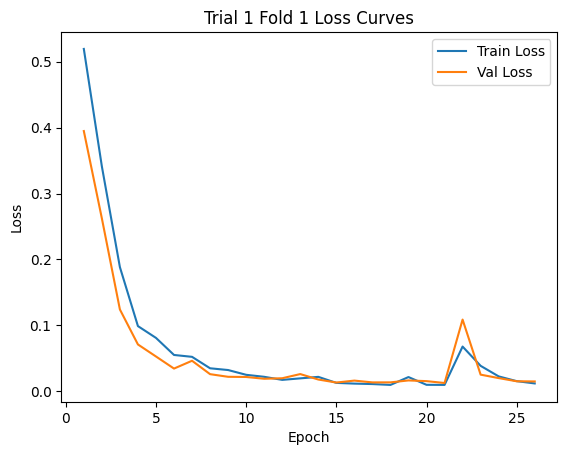

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 2, Epoch 1, Train Loss: 0.4948, Val Loss: 0.3721, F1: 0.3759, Acc: 0.8400
Fold 2, Epoch 2, Train Loss: 0.3185, Val Loss: 0.2268, F1: 0.6889, Acc: 0.9038
Fold 2, Epoch 3, Train Loss: 0.1644, Val Loss: 0.0989, F1: 0.9352, Acc: 0.9723
Fold 2, Epoch 4, Train Loss: 0.2058, Val Loss: 0.1173, F1: 0.9158, Acc: 0.9639
Fold 2, Epoch 5, Train Loss: 0.1009, Val Loss: 0.0593, F1: 0.9723, Acc: 0.9880
Fold 2, Epoch 6, Train Loss: 0.0578, Val Loss: 0.0416, F1: 0.9793, Acc: 0.9911
Fold 2, Epoch 7, Train Loss: 0.0518, Val Loss: 0.0390, F1: 0.9756, Acc: 0.9892
Fold 2, Epoch 8, Train Loss: 0.0348, Val Loss: 0.0285, F1: 0.9823, Acc: 0.9923
Fold 2, Epoch 9, Train Loss: 0.0278, Val Loss: 0.0294, F1: 0.9824, Acc: 0.9923
Fold 2, Epoch 10, Train Loss: 0.0314, Val Loss: 0.0263, F1: 0.9846, Acc: 0.9932
Fold 2, Epoch 11, Train Loss: 0.0205, Val Loss: 0.0221, F1: 0.9880, Acc: 0.9948
Fold 2, Epoch 12, Train Loss: 0.0252, Val Loss: 0.0202, F1: 0.9849, Acc: 0.9935
Fold 2, Epoch 13, Train Loss: 0.0249, Val Loss: 0

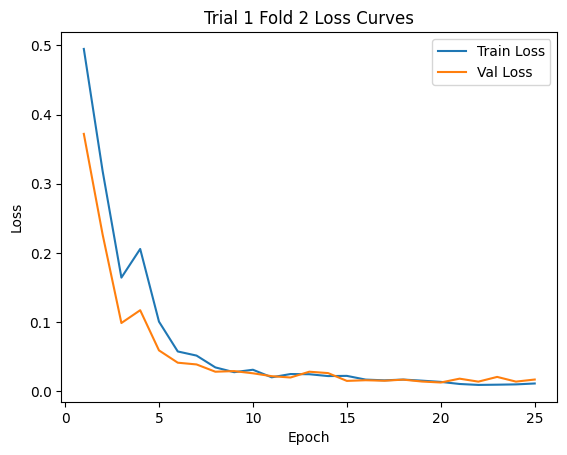

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 3, Epoch 1, Train Loss: 0.4915, Val Loss: 0.4076, F1: 0.4074, Acc: 0.8397
Fold 3, Epoch 2, Train Loss: 0.3220, Val Loss: 0.2384, F1: 0.5849, Acc: 0.8884
Fold 3, Epoch 3, Train Loss: 0.2015, Val Loss: 0.1366, F1: 0.8910, Acc: 0.9535
Fold 3, Epoch 4, Train Loss: 0.1226, Val Loss: 0.0906, F1: 0.9228, Acc: 0.9692
Fold 3, Epoch 5, Train Loss: 0.0802, Val Loss: 0.0557, F1: 0.9680, Acc: 0.9864
Fold 3, Epoch 6, Train Loss: 0.0912, Val Loss: 0.0486, F1: 0.9760, Acc: 0.9895
Fold 3, Epoch 7, Train Loss: 0.0435, Val Loss: 0.0321, F1: 0.9817, Acc: 0.9923
Fold 3, Epoch 8, Train Loss: 0.0426, Val Loss: 0.0243, F1: 0.9886, Acc: 0.9951
Fold 3, Epoch 9, Train Loss: 0.0299, Val Loss: 0.0205, F1: 0.9900, Acc: 0.9957
Fold 3, Epoch 10, Train Loss: 0.0431, Val Loss: 0.0201, F1: 0.9869, Acc: 0.9945
Fold 3, Epoch 11, Train Loss: 0.0201, Val Loss: 0.0162, F1: 0.9892, Acc: 0.9954
Fold 3, Epoch 12, Train Loss: 0.0172, Val Loss: 0.0138, F1: 0.9930, Acc: 0.9969
Fold 3, Epoch 13, Train Loss: 0.0142, Val Loss: 0

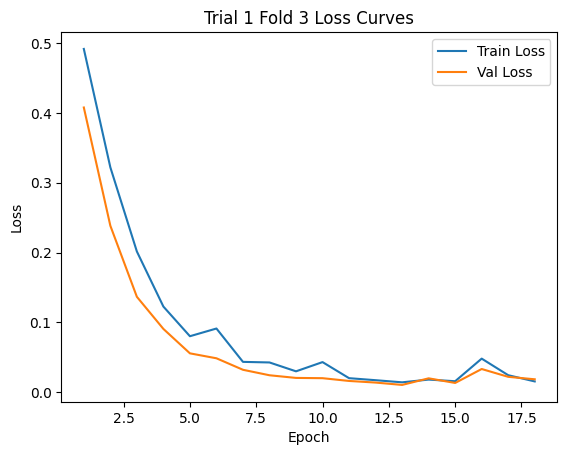

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 4, Epoch 1, Train Loss: 0.5095, Val Loss: 0.3808, F1: 0.3892, Acc: 0.8429
Fold 4, Epoch 2, Train Loss: 0.3323, Val Loss: 0.2752, F1: 0.5769, Acc: 0.8747
Fold 4, Epoch 3, Train Loss: 0.2398, Val Loss: 0.2171, F1: 0.7601, Acc: 0.9111
Fold 4, Epoch 4, Train Loss: 0.1503, Val Loss: 0.1000, F1: 0.9344, Acc: 0.9713
Fold 4, Epoch 5, Train Loss: 0.0930, Val Loss: 0.0687, F1: 0.9398, Acc: 0.9741
Fold 4, Epoch 6, Train Loss: 0.0821, Val Loss: 0.0867, F1: 0.9501, Acc: 0.9772
Fold 4, Epoch 7, Train Loss: 0.0647, Val Loss: 0.0348, F1: 0.9857, Acc: 0.9935
Fold 4, Epoch 8, Train Loss: 0.0375, Val Loss: 0.0236, F1: 0.9905, Acc: 0.9957
Fold 4, Epoch 9, Train Loss: 0.0320, Val Loss: 0.0245, F1: 0.9882, Acc: 0.9944
Fold 4, Epoch 10, Train Loss: 0.0336, Val Loss: 0.0331, F1: 0.9818, Acc: 0.9917
Fold 4, Epoch 11, Train Loss: 0.0297, Val Loss: 0.0234, F1: 0.9829, Acc: 0.9923
Fold 4, Epoch 12, Train Loss: 0.0231, Val Loss: 0.0134, F1: 0.9941, Acc: 0.9972
Fold 4, Epoch 13, Train Loss: 0.0280, Val Loss: 0

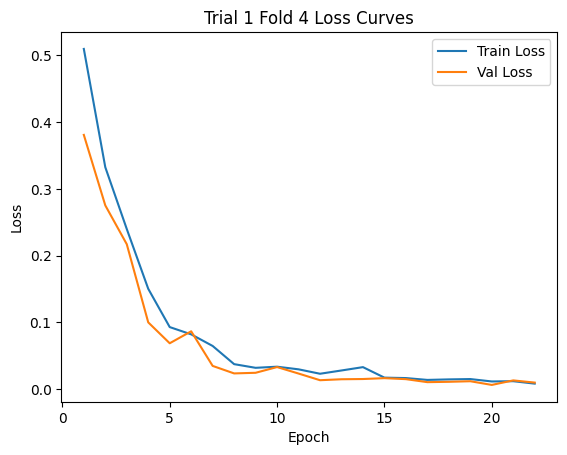

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 5, Epoch 1, Train Loss: 0.4800, Val Loss: 0.3842, F1: 0.4140, Acc: 0.8373
Fold 5, Epoch 2, Train Loss: 0.3201, Val Loss: 0.2852, F1: 0.6216, Acc: 0.8802
Fold 5, Epoch 3, Train Loss: 0.1766, Val Loss: 0.1082, F1: 0.9275, Acc: 0.9701
Fold 5, Epoch 4, Train Loss: 0.0953, Val Loss: 0.0756, F1: 0.9529, Acc: 0.9796
Fold 5, Epoch 5, Train Loss: 0.0606, Val Loss: 0.0532, F1: 0.9704, Acc: 0.9873
Fold 5, Epoch 6, Train Loss: 0.0561, Val Loss: 0.0446, F1: 0.9741, Acc: 0.9889
Fold 5, Epoch 7, Train Loss: 0.0352, Val Loss: 0.0302, F1: 0.9820, Acc: 0.9923
Fold 5, Epoch 8, Train Loss: 0.0322, Val Loss: 0.0258, F1: 0.9801, Acc: 0.9914
Fold 5, Epoch 9, Train Loss: 0.0247, Val Loss: 0.0154, F1: 0.9921, Acc: 0.9966
Fold 5, Epoch 10, Train Loss: 0.0734, Val Loss: 0.0287, F1: 0.9877, Acc: 0.9948
Fold 5, Epoch 11, Train Loss: 0.0315, Val Loss: 0.0161, F1: 0.9934, Acc: 0.9972
Fold 5, Epoch 12, Train Loss: 0.0303, Val Loss: 0.0271, F1: 0.9874, Acc: 0.9948
Fold 5, Epoch 13, Train Loss: 0.0182, Val Loss: 0

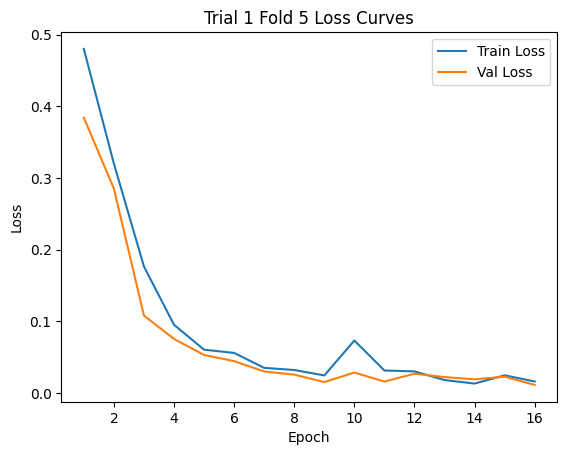

Trial 1 Mean F1: 0.9941

Trial 2, Params: {'batch_size': 32, 'lr': 0.0005, 'lstm_hidden': 32, 'tabular_hidden': 16, 'combined_hidden': 32, 'dropout': 0.1, 'bidirectional': True}


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 1, Epoch 1, Train Loss: 0.6015, Val Loss: 0.4907, F1: 0.0000, Acc: 0.7796
Fold 1, Epoch 2, Train Loss: 0.4368, Val Loss: 0.3771, F1: 0.3677, Acc: 0.8388
Fold 1, Epoch 3, Train Loss: 0.3482, Val Loss: 0.3198, F1: 0.5877, Acc: 0.8711
Fold 1, Epoch 4, Train Loss: 0.2930, Val Loss: 0.2601, F1: 0.6803, Acc: 0.8909
Fold 1, Epoch 5, Train Loss: 0.2333, Val Loss: 0.1906, F1: 0.7599, Acc: 0.9180
Fold 1, Epoch 6, Train Loss: 0.1624, Val Loss: 0.1298, F1: 0.9232, Acc: 0.9670
Fold 1, Epoch 7, Train Loss: 0.1124, Val Loss: 0.0945, F1: 0.9497, Acc: 0.9793
Fold 1, Epoch 8, Train Loss: 0.0844, Val Loss: 0.0686, F1: 0.9600, Acc: 0.9824
Fold 1, Epoch 9, Train Loss: 0.0650, Val Loss: 0.0619, F1: 0.9657, Acc: 0.9849
Fold 1, Epoch 10, Train Loss: 0.0752, Val Loss: 0.0523, F1: 0.9637, Acc: 0.9840
Fold 1, Epoch 11, Train Loss: 0.0531, Val Loss: 0.0422, F1: 0.9722, Acc: 0.9880
Fold 1, Epoch 12, Train Loss: 0.0415, Val Loss: 0.0372, F1: 0.9725, Acc: 0.9880
Fold 1, Epoch 13, Train Loss: 0.0376, Val Loss: 0

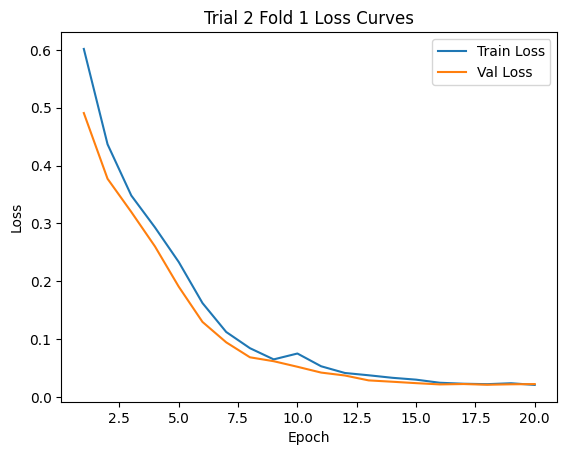

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 2, Epoch 1, Train Loss: 0.6028, Val Loss: 0.4893, F1: 0.0000, Acc: 0.7808
Fold 2, Epoch 2, Train Loss: 0.4369, Val Loss: 0.3894, F1: 0.3799, Acc: 0.8419
Fold 2, Epoch 3, Train Loss: 0.3608, Val Loss: 0.3178, F1: 0.5447, Acc: 0.8681
Fold 2, Epoch 4, Train Loss: 0.2969, Val Loss: 0.2697, F1: 0.6536, Acc: 0.8973
Fold 2, Epoch 5, Train Loss: 0.2536, Val Loss: 0.2288, F1: 0.6935, Acc: 0.9081
Fold 2, Epoch 6, Train Loss: 0.2265, Val Loss: 0.2015, F1: 0.7552, Acc: 0.9186
Fold 2, Epoch 7, Train Loss: 0.1885, Val Loss: 0.1731, F1: 0.8088, Acc: 0.9303
Fold 2, Epoch 8, Train Loss: 0.1696, Val Loss: 0.1520, F1: 0.8166, Acc: 0.9340
Fold 2, Epoch 9, Train Loss: 0.1480, Val Loss: 0.1373, F1: 0.8237, Acc: 0.9365
Fold 2, Epoch 10, Train Loss: 0.1311, Val Loss: 0.1218, F1: 0.8835, Acc: 0.9535
Fold 2, Epoch 11, Train Loss: 0.1158, Val Loss: 0.1080, F1: 0.9089, Acc: 0.9618
Fold 2, Epoch 12, Train Loss: 0.1064, Val Loss: 0.1005, F1: 0.9097, Acc: 0.9624
Fold 2, Epoch 13, Train Loss: 0.0980, Val Loss: 0

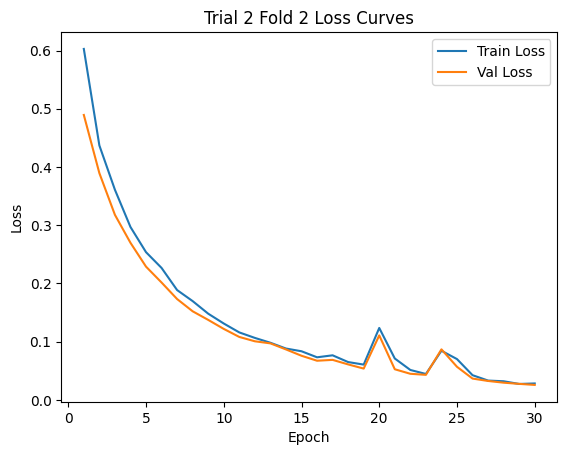

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 3, Epoch 1, Train Loss: 0.6194, Val Loss: 0.4931, F1: 0.0000, Acc: 0.7824
Fold 3, Epoch 2, Train Loss: 0.4441, Val Loss: 0.3804, F1: 0.4043, Acc: 0.8517
Fold 3, Epoch 3, Train Loss: 0.3416, Val Loss: 0.2918, F1: 0.6577, Acc: 0.8878
Fold 3, Epoch 4, Train Loss: 0.2572, Val Loss: 0.2174, F1: 0.8040, Acc: 0.9239
Fold 3, Epoch 5, Train Loss: 0.1823, Val Loss: 0.1657, F1: 0.8523, Acc: 0.9402
Fold 3, Epoch 6, Train Loss: 0.1359, Val Loss: 0.1420, F1: 0.8876, Acc: 0.9550
Fold 3, Epoch 7, Train Loss: 0.1097, Val Loss: 0.0923, F1: 0.9356, Acc: 0.9738
Fold 3, Epoch 8, Train Loss: 0.0851, Val Loss: 0.0730, F1: 0.9496, Acc: 0.9784
Fold 3, Epoch 9, Train Loss: 0.0711, Val Loss: 0.0875, F1: 0.9488, Acc: 0.9787
Fold 3, Epoch 10, Train Loss: 0.0587, Val Loss: 0.0459, F1: 0.9684, Acc: 0.9864
Fold 3, Epoch 11, Train Loss: 0.0434, Val Loss: 0.0427, F1: 0.9704, Acc: 0.9874
Fold 3, Epoch 12, Train Loss: 0.0382, Val Loss: 0.0332, F1: 0.9851, Acc: 0.9935
Fold 3, Epoch 13, Train Loss: 0.0286, Val Loss: 0

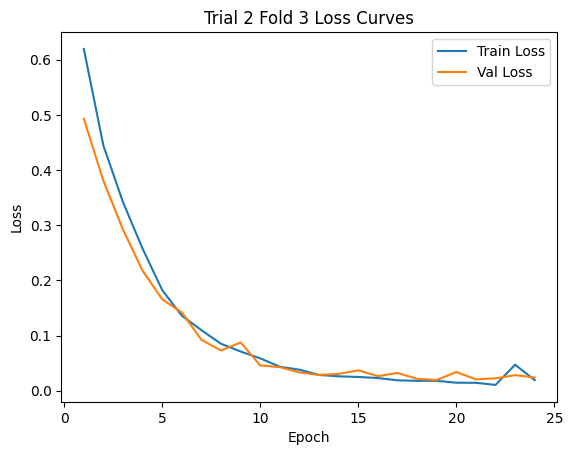

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 4, Epoch 1, Train Loss: 0.5966, Val Loss: 0.5234, F1: 0.0000, Acc: 0.7651
Fold 4, Epoch 2, Train Loss: 0.4665, Val Loss: 0.4284, F1: 0.3865, Acc: 0.8306
Fold 4, Epoch 3, Train Loss: 0.3868, Val Loss: 0.3483, F1: 0.5311, Acc: 0.8534
Fold 4, Epoch 4, Train Loss: 0.3113, Val Loss: 0.2579, F1: 0.7391, Acc: 0.9083
Fold 4, Epoch 5, Train Loss: 0.2288, Val Loss: 0.1874, F1: 0.8282, Acc: 0.9333
Fold 4, Epoch 6, Train Loss: 0.1688, Val Loss: 0.1358, F1: 0.8932, Acc: 0.9577
Fold 4, Epoch 7, Train Loss: 0.1296, Val Loss: 0.1068, F1: 0.9297, Acc: 0.9704
Fold 4, Epoch 8, Train Loss: 0.1029, Val Loss: 0.0862, F1: 0.9396, Acc: 0.9741
Fold 4, Epoch 9, Train Loss: 0.0826, Val Loss: 0.0676, F1: 0.9575, Acc: 0.9812
Fold 4, Epoch 10, Train Loss: 0.0735, Val Loss: 0.0810, F1: 0.9345, Acc: 0.9722
Fold 4, Epoch 11, Train Loss: 0.0774, Val Loss: 0.0671, F1: 0.9463, Acc: 0.9769
Fold 4, Epoch 12, Train Loss: 0.0572, Val Loss: 0.0512, F1: 0.9643, Acc: 0.9840
Fold 4, Epoch 13, Train Loss: 0.0522, Val Loss: 0

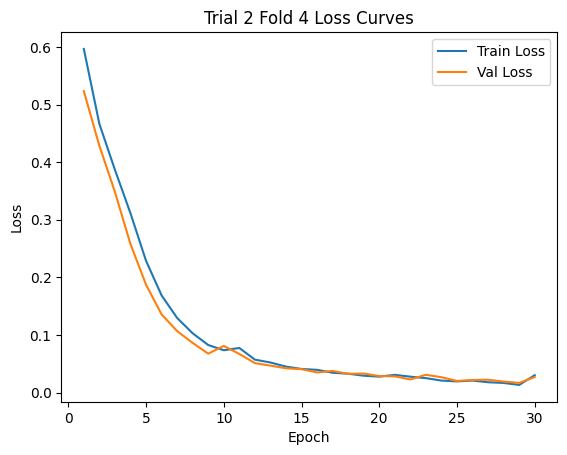

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 5, Epoch 1, Train Loss: 0.5638, Val Loss: 0.4706, F1: 0.0314, Acc: 0.7886
Fold 5, Epoch 2, Train Loss: 0.4315, Val Loss: 0.3854, F1: 0.2310, Acc: 0.8160
Fold 5, Epoch 3, Train Loss: 0.3472, Val Loss: 0.2986, F1: 0.4278, Acc: 0.8543
Fold 5, Epoch 4, Train Loss: 0.2676, Val Loss: 0.2224, F1: 0.7329, Acc: 0.9074
Fold 5, Epoch 5, Train Loss: 0.1964, Val Loss: 0.1629, F1: 0.8676, Acc: 0.9475
Fold 5, Epoch 6, Train Loss: 0.1433, Val Loss: 0.1109, F1: 0.9220, Acc: 0.9676
Fold 5, Epoch 7, Train Loss: 0.1081, Val Loss: 0.1177, F1: 0.9077, Acc: 0.9599
Fold 5, Epoch 8, Train Loss: 0.0870, Val Loss: 0.0645, F1: 0.9587, Acc: 0.9821
Fold 5, Epoch 9, Train Loss: 0.0666, Val Loss: 0.0517, F1: 0.9643, Acc: 0.9846
Fold 5, Epoch 10, Train Loss: 0.0568, Val Loss: 0.0429, F1: 0.9742, Acc: 0.9886
Fold 5, Epoch 11, Train Loss: 0.0452, Val Loss: 0.0351, F1: 0.9782, Acc: 0.9904
Fold 5, Epoch 12, Train Loss: 0.0393, Val Loss: 0.0289, F1: 0.9868, Acc: 0.9941
Fold 5, Epoch 13, Train Loss: 0.0341, Val Loss: 0

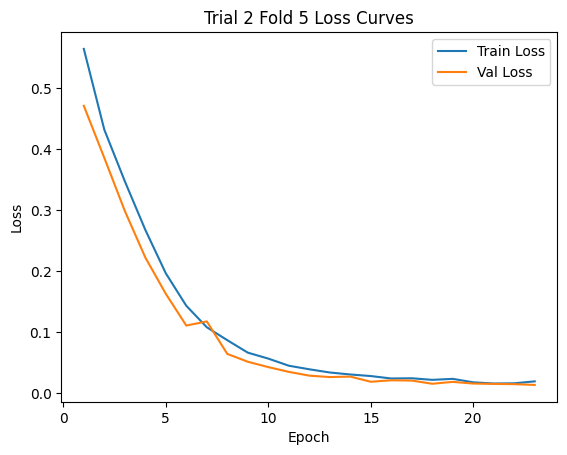

Trial 2 Mean F1: 0.9913

Trial 3, Params: {'batch_size': 32, 'lr': 0.001, 'lstm_hidden': 64, 'tabular_hidden': 16, 'combined_hidden': 64, 'dropout': 0.3, 'bidirectional': True}


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 1, Epoch 1, Train Loss: 0.4801, Val Loss: 0.3481, F1: 0.4940, Acc: 0.8671
Fold 1, Epoch 2, Train Loss: 0.3335, Val Loss: 0.2877, F1: 0.5363, Acc: 0.8678
Fold 1, Epoch 3, Train Loss: 0.2430, Val Loss: 0.1828, F1: 0.7073, Acc: 0.9131
Fold 1, Epoch 4, Train Loss: 0.1466, Val Loss: 0.1293, F1: 0.8741, Acc: 0.9513
Fold 1, Epoch 5, Train Loss: 0.1041, Val Loss: 0.0801, F1: 0.9414, Acc: 0.9744
Fold 1, Epoch 6, Train Loss: 0.0734, Val Loss: 0.0425, F1: 0.9733, Acc: 0.9886
Fold 1, Epoch 7, Train Loss: 0.0558, Val Loss: 0.0493, F1: 0.9624, Acc: 0.9843
Fold 1, Epoch 8, Train Loss: 0.0610, Val Loss: 0.1060, F1: 0.9107, Acc: 0.9645
Fold 1, Epoch 9, Train Loss: 0.0480, Val Loss: 0.0275, F1: 0.9851, Acc: 0.9935
Fold 1, Epoch 10, Train Loss: 0.0456, Val Loss: 0.0363, F1: 0.9746, Acc: 0.9883
Fold 1, Epoch 11, Train Loss: 0.0315, Val Loss: 0.0216, F1: 0.9859, Acc: 0.9938
Fold 1, Epoch 12, Train Loss: 0.0287, Val Loss: 0.0165, F1: 0.9902, Acc: 0.9957
Fold 1, Epoch 13, Train Loss: 0.0257, Val Loss: 0

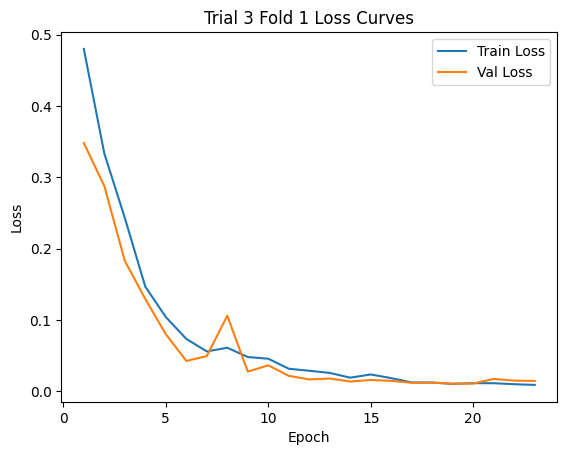

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 2, Epoch 1, Train Loss: 0.4660, Val Loss: 0.3428, F1: 0.4578, Acc: 0.8477
Fold 2, Epoch 2, Train Loss: 0.2841, Val Loss: 0.1906, F1: 0.7509, Acc: 0.9186
Fold 2, Epoch 3, Train Loss: 0.1553, Val Loss: 0.0911, F1: 0.9322, Acc: 0.9707
Fold 2, Epoch 4, Train Loss: 0.1535, Val Loss: 0.0753, F1: 0.9561, Acc: 0.9809
Fold 2, Epoch 5, Train Loss: 0.0907, Val Loss: 0.0501, F1: 0.9720, Acc: 0.9877
Fold 2, Epoch 6, Train Loss: 0.0580, Val Loss: 0.0447, F1: 0.9655, Acc: 0.9849
Fold 2, Epoch 7, Train Loss: 0.0430, Val Loss: 0.0302, F1: 0.9848, Acc: 0.9932
Fold 2, Epoch 8, Train Loss: 0.0342, Val Loss: 0.0222, F1: 0.9867, Acc: 0.9941
Fold 2, Epoch 9, Train Loss: 0.0272, Val Loss: 0.0194, F1: 0.9881, Acc: 0.9948
Fold 2, Epoch 10, Train Loss: 0.0269, Val Loss: 0.0156, F1: 0.9912, Acc: 0.9963
Fold 2, Epoch 11, Train Loss: 0.0235, Val Loss: 0.0234, F1: 0.9832, Acc: 0.9926
Fold 2, Epoch 12, Train Loss: 0.0486, Val Loss: 0.0890, F1: 0.9020, Acc: 0.9531
Fold 2, Epoch 13, Train Loss: 0.0518, Val Loss: 0

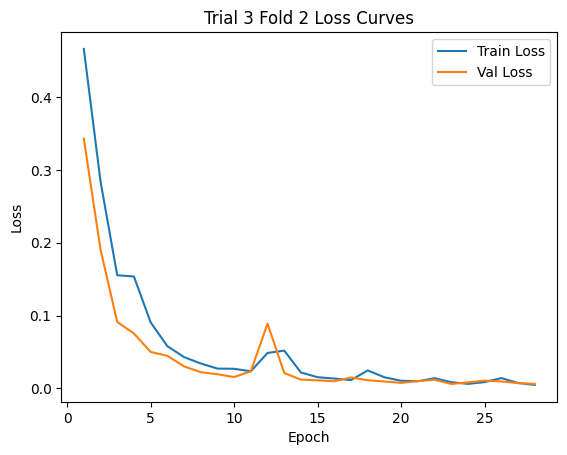

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 3, Epoch 1, Train Loss: 0.4757, Val Loss: 0.3286, F1: 0.4039, Acc: 0.8554
Fold 3, Epoch 2, Train Loss: 0.2536, Val Loss: 0.1498, F1: 0.8935, Acc: 0.9544
Fold 3, Epoch 3, Train Loss: 0.1126, Val Loss: 0.0789, F1: 0.9272, Acc: 0.9726
Fold 3, Epoch 4, Train Loss: 0.0849, Val Loss: 0.2182, F1: 0.8182, Acc: 0.9171
Fold 3, Epoch 5, Train Loss: 0.0946, Val Loss: 0.0514, F1: 0.9641, Acc: 0.9843
Fold 3, Epoch 6, Train Loss: 0.0427, Val Loss: 0.0350, F1: 0.9788, Acc: 0.9908
Fold 3, Epoch 7, Train Loss: 0.0327, Val Loss: 0.0189, F1: 0.9879, Acc: 0.9948
Fold 3, Epoch 8, Train Loss: 0.0289, Val Loss: 0.0208, F1: 0.9852, Acc: 0.9935
Fold 3, Epoch 9, Train Loss: 0.0224, Val Loss: 0.0163, F1: 0.9886, Acc: 0.9951
Fold 3, Epoch 10, Train Loss: 0.0189, Val Loss: 0.0139, F1: 0.9902, Acc: 0.9957
Fold 3, Epoch 11, Train Loss: 0.0150, Val Loss: 0.0116, F1: 0.9951, Acc: 0.9978
Fold 3, Epoch 12, Train Loss: 0.0168, Val Loss: 0.0119, F1: 0.9914, Acc: 0.9963
Fold 3, Epoch 13, Train Loss: 0.0133, Val Loss: 0

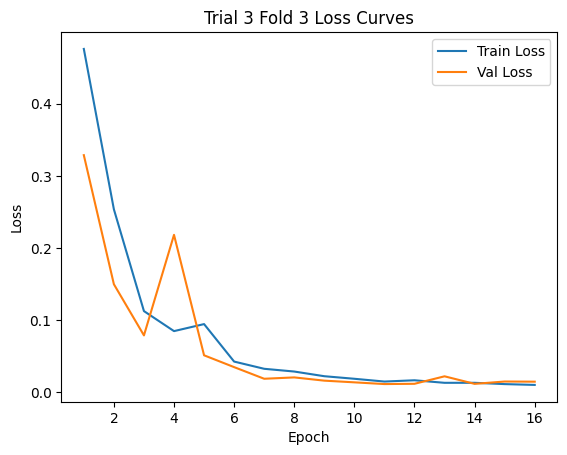

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 4, Epoch 1, Train Loss: 0.4827, Val Loss: 0.3409, F1: 0.4108, Acc: 0.8478
Fold 4, Epoch 2, Train Loss: 0.2358, Val Loss: 0.1335, F1: 0.8901, Acc: 0.9503
Fold 4, Epoch 3, Train Loss: 0.1139, Val Loss: 0.0866, F1: 0.9396, Acc: 0.9731
Fold 4, Epoch 4, Train Loss: 0.0630, Val Loss: 0.0407, F1: 0.9865, Acc: 0.9935
Fold 4, Epoch 5, Train Loss: 0.0392, Val Loss: 0.0238, F1: 0.9882, Acc: 0.9944
Fold 4, Epoch 6, Train Loss: 0.0413, Val Loss: 0.0175, F1: 0.9913, Acc: 0.9960
Fold 4, Epoch 7, Train Loss: 0.0315, Val Loss: 0.0473, F1: 0.9639, Acc: 0.9830
Fold 4, Epoch 8, Train Loss: 0.0286, Val Loss: 0.0138, F1: 0.9934, Acc: 0.9969
Fold 4, Epoch 9, Train Loss: 0.0216, Val Loss: 0.0154, F1: 0.9900, Acc: 0.9954
Fold 4, Epoch 10, Train Loss: 0.0228, Val Loss: 0.0147, F1: 0.9906, Acc: 0.9957
Fold 4, Epoch 11, Train Loss: 0.0196, Val Loss: 0.0141, F1: 0.9927, Acc: 0.9966
Fold 4, Epoch 12, Train Loss: 0.0188, Val Loss: 0.0100, F1: 0.9949, Acc: 0.9975
Fold 4, Epoch 13, Train Loss: 0.0177, Val Loss: 0

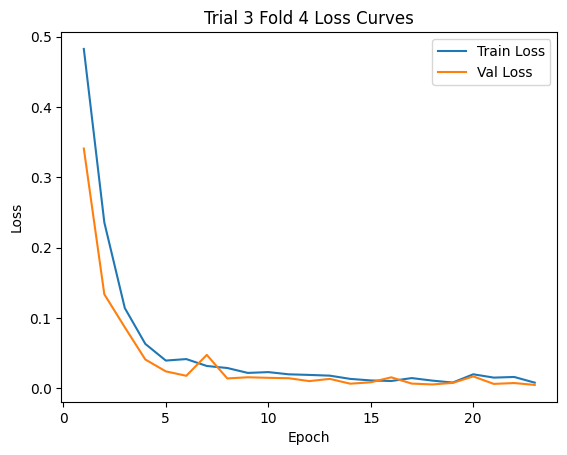

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 5, Epoch 1, Train Loss: 0.4631, Val Loss: 0.3146, F1: 0.3823, Acc: 0.8438
Fold 5, Epoch 2, Train Loss: 0.2273, Val Loss: 0.1289, F1: 0.9279, Acc: 0.9701
Fold 5, Epoch 3, Train Loss: 0.1099, Val Loss: 0.0542, F1: 0.9606, Acc: 0.9833
Fold 5, Epoch 4, Train Loss: 0.0793, Val Loss: 0.0594, F1: 0.9696, Acc: 0.9870
Fold 5, Epoch 5, Train Loss: 0.0501, Val Loss: 0.0243, F1: 0.9870, Acc: 0.9944
Fold 5, Epoch 6, Train Loss: 0.0367, Val Loss: 0.0511, F1: 0.9639, Acc: 0.9840
Fold 5, Epoch 7, Train Loss: 0.0380, Val Loss: 0.0190, F1: 0.9870, Acc: 0.9944
Fold 5, Epoch 8, Train Loss: 0.0278, Val Loss: 0.2338, F1: 0.8665, Acc: 0.9238
Fold 5, Epoch 9, Train Loss: 0.0571, Val Loss: 0.0269, F1: 0.9790, Acc: 0.9910
Fold 5, Epoch 10, Train Loss: 0.0270, Val Loss: 0.0194, F1: 0.9890, Acc: 0.9954
Fold 5, Epoch 11, Train Loss: 0.0207, Val Loss: 0.0128, F1: 0.9905, Acc: 0.9960
Fold 5, Epoch 12, Train Loss: 0.0213, Val Loss: 0.0219, F1: 0.9819, Acc: 0.9923
Fold 5, Epoch 13, Train Loss: 0.0149, Val Loss: 0

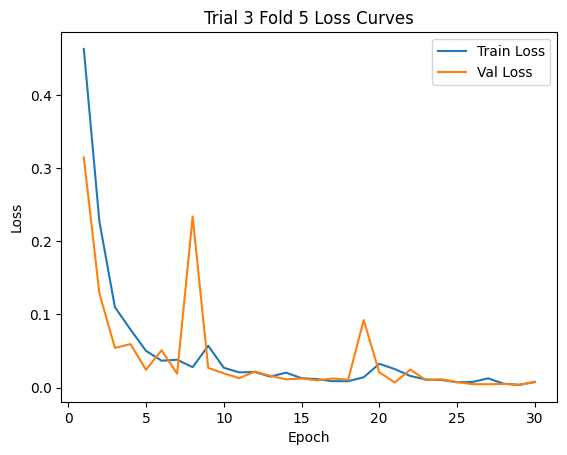

Trial 3 Mean F1: 0.9962

Trial 4, Params: {'batch_size': 32, 'lr': 0.0005, 'lstm_hidden': 64, 'tabular_hidden': 32, 'combined_hidden': 32, 'dropout': 0.1, 'bidirectional': False}


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 1, Epoch 1, Train Loss: 0.5601, Val Loss: 0.4312, F1: 0.1950, Acc: 0.8043
Fold 1, Epoch 2, Train Loss: 0.3728, Val Loss: 0.3112, F1: 0.4983, Acc: 0.8711
Fold 1, Epoch 3, Train Loss: 0.2855, Val Loss: 0.2438, F1: 0.7208, Acc: 0.9044
Fold 1, Epoch 4, Train Loss: 0.2224, Val Loss: 0.1855, F1: 0.8243, Acc: 0.9313
Fold 1, Epoch 5, Train Loss: 0.1750, Val Loss: 0.1530, F1: 0.8746, Acc: 0.9510
Fold 1, Epoch 6, Train Loss: 0.1493, Val Loss: 0.1315, F1: 0.8931, Acc: 0.9590
Fold 1, Epoch 7, Train Loss: 0.1188, Val Loss: 0.0987, F1: 0.9235, Acc: 0.9695
Fold 1, Epoch 8, Train Loss: 0.0911, Val Loss: 0.0711, F1: 0.9456, Acc: 0.9778
Fold 1, Epoch 9, Train Loss: 0.0694, Val Loss: 0.0532, F1: 0.9640, Acc: 0.9849
Fold 1, Epoch 10, Train Loss: 0.0561, Val Loss: 0.0451, F1: 0.9668, Acc: 0.9861
Fold 1, Epoch 11, Train Loss: 0.0450, Val Loss: 0.0371, F1: 0.9718, Acc: 0.9880
Fold 1, Epoch 12, Train Loss: 0.0432, Val Loss: 0.0319, F1: 0.9815, Acc: 0.9920
Fold 1, Epoch 13, Train Loss: 0.0280, Val Loss: 0

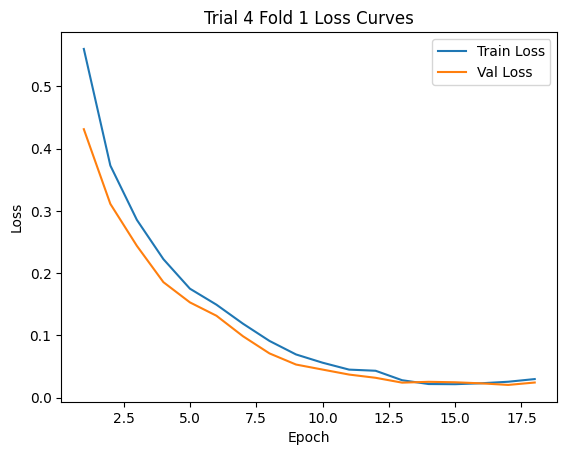

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 2, Epoch 1, Train Loss: 0.5513, Val Loss: 0.4211, F1: 0.3724, Acc: 0.8357
Fold 2, Epoch 2, Train Loss: 0.3757, Val Loss: 0.3174, F1: 0.4977, Acc: 0.8557
Fold 2, Epoch 3, Train Loss: 0.3236, Val Loss: 0.2836, F1: 0.6093, Acc: 0.8752
Fold 2, Epoch 4, Train Loss: 0.2535, Val Loss: 0.2107, F1: 0.7731, Acc: 0.9217
Fold 2, Epoch 5, Train Loss: 0.2005, Val Loss: 0.1818, F1: 0.8407, Acc: 0.9350
Fold 2, Epoch 6, Train Loss: 0.1759, Val Loss: 0.1445, F1: 0.8838, Acc: 0.9516
Fold 2, Epoch 7, Train Loss: 0.1579, Val Loss: 0.1253, F1: 0.9006, Acc: 0.9565
Fold 2, Epoch 8, Train Loss: 0.1261, Val Loss: 0.1045, F1: 0.9331, Acc: 0.9701
Fold 2, Epoch 9, Train Loss: 0.1101, Val Loss: 0.0980, F1: 0.9287, Acc: 0.9664
Fold 2, Epoch 10, Train Loss: 0.0894, Val Loss: 0.0747, F1: 0.9533, Acc: 0.9790
Fold 2, Epoch 11, Train Loss: 0.0744, Val Loss: 0.0589, F1: 0.9657, Acc: 0.9849
Fold 2, Epoch 12, Train Loss: 0.0716, Val Loss: 0.0470, F1: 0.9788, Acc: 0.9904
Fold 2, Epoch 13, Train Loss: 0.0885, Val Loss: 0

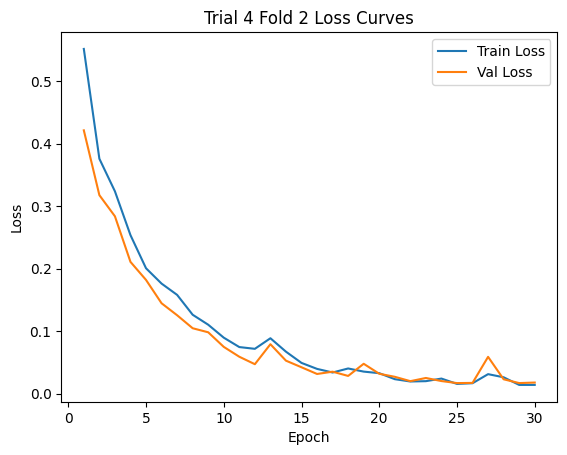

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 3, Epoch 1, Train Loss: 0.5371, Val Loss: 0.4112, F1: 0.2831, Acc: 0.8295
Fold 3, Epoch 2, Train Loss: 0.3669, Val Loss: 0.3062, F1: 0.4115, Acc: 0.8588
Fold 3, Epoch 3, Train Loss: 0.2648, Val Loss: 0.2081, F1: 0.7803, Acc: 0.9202
Fold 3, Epoch 4, Train Loss: 0.2002, Val Loss: 0.1643, F1: 0.8478, Acc: 0.9417
Fold 3, Epoch 5, Train Loss: 0.1486, Val Loss: 0.1240, F1: 0.8941, Acc: 0.9565
Fold 3, Epoch 6, Train Loss: 0.1165, Val Loss: 0.1043, F1: 0.9131, Acc: 0.9645
Fold 3, Epoch 7, Train Loss: 0.0956, Val Loss: 0.0754, F1: 0.9495, Acc: 0.9790
Fold 3, Epoch 8, Train Loss: 0.0727, Val Loss: 0.0641, F1: 0.9539, Acc: 0.9809
Fold 3, Epoch 9, Train Loss: 0.0801, Val Loss: 0.1274, F1: 0.8910, Acc: 0.9494
Fold 3, Epoch 10, Train Loss: 0.0698, Val Loss: 0.0645, F1: 0.9541, Acc: 0.9806
Fold 3, Epoch 11, Train Loss: 0.0495, Val Loss: 0.0365, F1: 0.9781, Acc: 0.9908
Fold 3, Epoch 12, Train Loss: 0.0392, Val Loss: 0.0410, F1: 0.9690, Acc: 0.9877
Fold 3, Epoch 13, Train Loss: 0.0323, Val Loss: 0

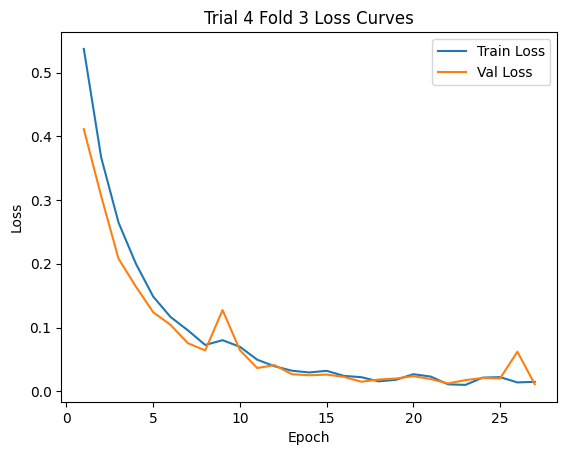

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 4, Epoch 1, Train Loss: 0.5530, Val Loss: 0.4509, F1: 0.1851, Acc: 0.8028
Fold 4, Epoch 2, Train Loss: 0.3950, Val Loss: 0.3534, F1: 0.5515, Acc: 0.8571
Fold 4, Epoch 3, Train Loss: 0.3147, Val Loss: 0.2826, F1: 0.6790, Acc: 0.8895
Fold 4, Epoch 4, Train Loss: 0.2460, Val Loss: 0.2168, F1: 0.8030, Acc: 0.9272
Fold 4, Epoch 5, Train Loss: 0.1810, Val Loss: 0.1424, F1: 0.8736, Acc: 0.9478
Fold 4, Epoch 6, Train Loss: 0.1286, Val Loss: 0.1026, F1: 0.9190, Acc: 0.9645
Fold 4, Epoch 7, Train Loss: 0.0980, Val Loss: 0.0801, F1: 0.9354, Acc: 0.9704
Fold 4, Epoch 8, Train Loss: 0.0794, Val Loss: 0.0594, F1: 0.9607, Acc: 0.9824
Fold 4, Epoch 9, Train Loss: 0.0589, Val Loss: 0.0460, F1: 0.9687, Acc: 0.9864
Fold 4, Epoch 10, Train Loss: 0.0572, Val Loss: 0.0432, F1: 0.9753, Acc: 0.9889
Fold 4, Epoch 11, Train Loss: 0.0409, Val Loss: 0.0270, F1: 0.9854, Acc: 0.9935
Fold 4, Epoch 12, Train Loss: 0.0343, Val Loss: 0.0342, F1: 0.9747, Acc: 0.9886
Fold 4, Epoch 13, Train Loss: 0.0416, Val Loss: 0

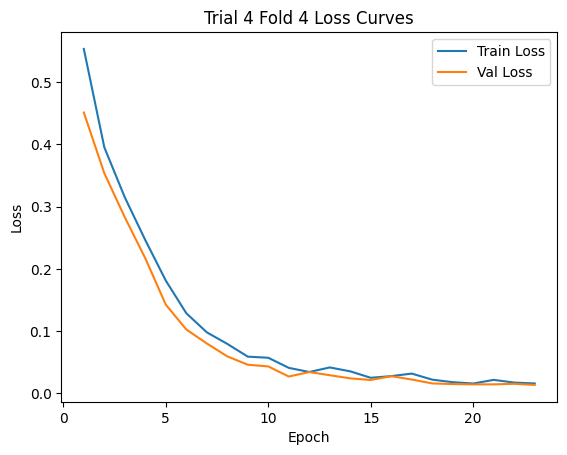

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 5, Epoch 1, Train Loss: 0.5393, Val Loss: 0.4135, F1: 0.1620, Acc: 0.8086
Fold 5, Epoch 2, Train Loss: 0.3515, Val Loss: 0.3063, F1: 0.5014, Acc: 0.8673
Fold 5, Epoch 3, Train Loss: 0.2648, Val Loss: 0.2238, F1: 0.6744, Acc: 0.8978
Fold 5, Epoch 4, Train Loss: 0.2116, Val Loss: 0.1827, F1: 0.8188, Acc: 0.9272
Fold 5, Epoch 5, Train Loss: 0.1715, Val Loss: 0.1760, F1: 0.8064, Acc: 0.9321
Fold 5, Epoch 6, Train Loss: 0.1353, Val Loss: 0.1050, F1: 0.9420, Acc: 0.9759
Fold 5, Epoch 7, Train Loss: 0.1033, Val Loss: 0.0875, F1: 0.9475, Acc: 0.9784
Fold 5, Epoch 8, Train Loss: 0.0856, Val Loss: 0.0807, F1: 0.9455, Acc: 0.9769
Fold 5, Epoch 9, Train Loss: 0.0709, Val Loss: 0.0492, F1: 0.9696, Acc: 0.9870
Fold 5, Epoch 10, Train Loss: 0.0515, Val Loss: 0.0450, F1: 0.9689, Acc: 0.9867
Fold 5, Epoch 11, Train Loss: 0.0461, Val Loss: 0.0410, F1: 0.9771, Acc: 0.9901
Fold 5, Epoch 12, Train Loss: 0.0390, Val Loss: 0.0315, F1: 0.9841, Acc: 0.9932
Fold 5, Epoch 13, Train Loss: 0.0400, Val Loss: 0

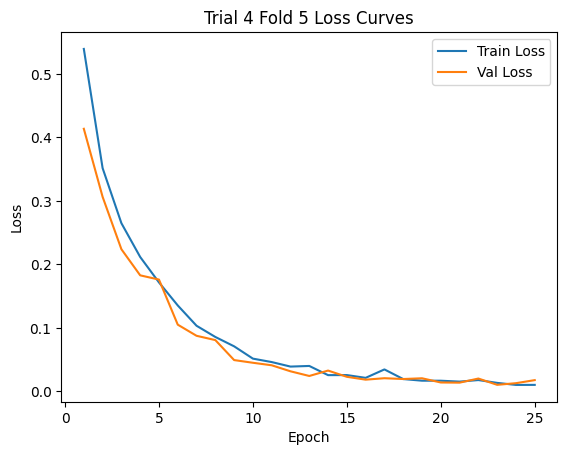

Trial 4 Mean F1: 0.9929

Trial 5, Params: {'batch_size': 32, 'lr': 0.001, 'lstm_hidden': 64, 'tabular_hidden': 16, 'combined_hidden': 64, 'dropout': 0.3, 'bidirectional': False}


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 1, Epoch 1, Train Loss: 0.5063, Val Loss: 0.3686, F1: 0.2677, Acc: 0.8311
Fold 1, Epoch 2, Train Loss: 0.3340, Val Loss: 0.2311, F1: 0.7343, Acc: 0.9109
Fold 1, Epoch 3, Train Loss: 0.1799, Val Loss: 0.1179, F1: 0.9154, Acc: 0.9652
Fold 1, Epoch 4, Train Loss: 0.1019, Val Loss: 0.0662, F1: 0.9494, Acc: 0.9787
Fold 1, Epoch 5, Train Loss: 0.0695, Val Loss: 0.0440, F1: 0.9716, Acc: 0.9880
Fold 1, Epoch 6, Train Loss: 0.0453, Val Loss: 0.0475, F1: 0.9681, Acc: 0.9861
Fold 1, Epoch 7, Train Loss: 0.0488, Val Loss: 0.0494, F1: 0.9648, Acc: 0.9846
Fold 1, Epoch 8, Train Loss: 0.0451, Val Loss: 0.0354, F1: 0.9784, Acc: 0.9904
Fold 1, Epoch 9, Train Loss: 0.0241, Val Loss: 0.0255, F1: 0.9842, Acc: 0.9929
Fold 1, Epoch 10, Train Loss: 0.0213, Val Loss: 0.0255, F1: 0.9895, Acc: 0.9954
Fold 1, Epoch 11, Train Loss: 0.0181, Val Loss: 0.0184, F1: 0.9909, Acc: 0.9960
Fold 1, Epoch 12, Train Loss: 0.0159, Val Loss: 0.0171, F1: 0.9922, Acc: 0.9966
Fold 1, Epoch 13, Train Loss: 0.0152, Val Loss: 0

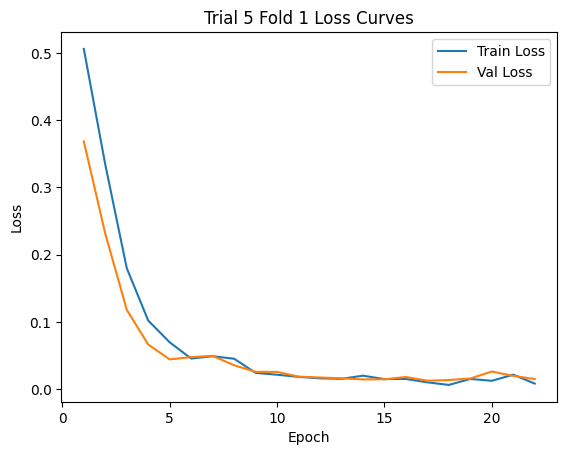

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 2, Epoch 1, Train Loss: 0.4896, Val Loss: 0.3695, F1: 0.4020, Acc: 0.8419
Fold 2, Epoch 2, Train Loss: 0.3160, Val Loss: 0.1909, F1: 0.8077, Acc: 0.9282
Fold 2, Epoch 3, Train Loss: 0.1548, Val Loss: 0.0929, F1: 0.9207, Acc: 0.9664
Fold 2, Epoch 4, Train Loss: 0.0919, Val Loss: 0.0481, F1: 0.9664, Acc: 0.9852
Fold 2, Epoch 5, Train Loss: 0.0493, Val Loss: 0.0316, F1: 0.9817, Acc: 0.9920
Fold 2, Epoch 6, Train Loss: 0.0481, Val Loss: 0.0346, F1: 0.9780, Acc: 0.9901
Fold 2, Epoch 7, Train Loss: 0.0329, Val Loss: 0.0266, F1: 0.9851, Acc: 0.9935
Fold 2, Epoch 8, Train Loss: 0.0253, Val Loss: 0.0302, F1: 0.9833, Acc: 0.9929
Fold 2, Epoch 9, Train Loss: 0.0227, Val Loss: 0.0184, F1: 0.9888, Acc: 0.9951
Fold 2, Epoch 10, Train Loss: 0.0195, Val Loss: 0.0236, F1: 0.9887, Acc: 0.9951
Fold 2, Epoch 11, Train Loss: 0.0155, Val Loss: 0.0168, F1: 0.9886, Acc: 0.9951
Fold 2, Epoch 12, Train Loss: 0.0147, Val Loss: 0.0176, F1: 0.9879, Acc: 0.9948
Fold 2, Epoch 13, Train Loss: 0.0195, Val Loss: 0

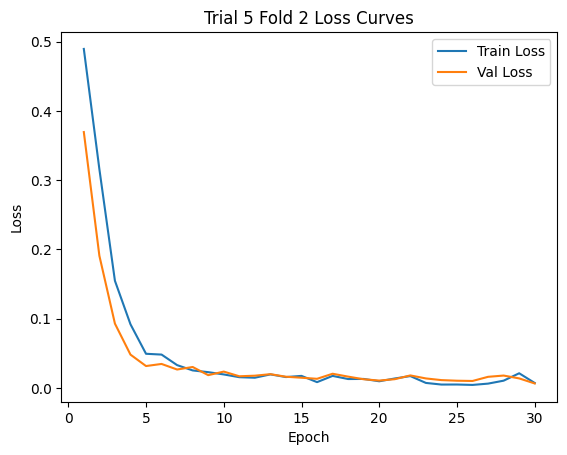

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 3, Epoch 1, Train Loss: 0.5067, Val Loss: 0.3500, F1: 0.4395, Acc: 0.8468
Fold 3, Epoch 2, Train Loss: 0.2552, Val Loss: 0.1866, F1: 0.8142, Acc: 0.9251
Fold 3, Epoch 3, Train Loss: 0.1498, Val Loss: 0.1525, F1: 0.8193, Acc: 0.9377
Fold 3, Epoch 4, Train Loss: 0.1186, Val Loss: 0.0953, F1: 0.9180, Acc: 0.9649
Fold 3, Epoch 5, Train Loss: 0.1019, Val Loss: 0.0711, F1: 0.9456, Acc: 0.9772
Fold 3, Epoch 6, Train Loss: 0.0685, Val Loss: 0.0636, F1: 0.9470, Acc: 0.9778
Fold 3, Epoch 7, Train Loss: 0.0492, Val Loss: 0.0397, F1: 0.9686, Acc: 0.9871
Fold 3, Epoch 8, Train Loss: 0.0367, Val Loss: 0.0330, F1: 0.9785, Acc: 0.9911
Fold 3, Epoch 9, Train Loss: 0.0341, Val Loss: 0.0630, F1: 0.9582, Acc: 0.9818
Fold 3, Epoch 10, Train Loss: 0.0380, Val Loss: 0.0238, F1: 0.9864, Acc: 0.9941
Fold 3, Epoch 11, Train Loss: 0.0262, Val Loss: 0.0217, F1: 0.9915, Acc: 0.9963
Fold 3, Epoch 12, Train Loss: 0.0300, Val Loss: 0.0442, F1: 0.9670, Acc: 0.9855
Fold 3, Epoch 13, Train Loss: 0.0337, Val Loss: 0

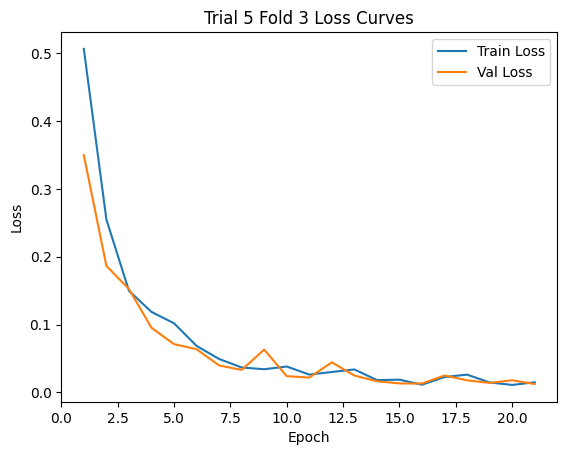

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 4, Epoch 1, Train Loss: 0.4893, Val Loss: 0.3302, F1: 0.4749, Acc: 0.8441
Fold 4, Epoch 2, Train Loss: 0.2213, Val Loss: 0.1380, F1: 0.8749, Acc: 0.9519
Fold 4, Epoch 3, Train Loss: 0.1163, Val Loss: 0.1180, F1: 0.9158, Acc: 0.9617
Fold 4, Epoch 4, Train Loss: 0.0794, Val Loss: 0.0467, F1: 0.9653, Acc: 0.9846
Fold 4, Epoch 5, Train Loss: 0.0510, Val Loss: 0.0529, F1: 0.9659, Acc: 0.9846
Fold 4, Epoch 6, Train Loss: 0.0423, Val Loss: 0.0458, F1: 0.9734, Acc: 0.9877
Fold 4, Epoch 7, Train Loss: 0.0365, Val Loss: 0.0324, F1: 0.9827, Acc: 0.9923
Fold 4, Epoch 8, Train Loss: 0.0491, Val Loss: 0.0297, F1: 0.9861, Acc: 0.9935
Fold 4, Epoch 9, Train Loss: 0.0248, Val Loss: 0.0386, F1: 0.9768, Acc: 0.9895
Fold 4, Epoch 10, Train Loss: 0.0330, Val Loss: 0.0248, F1: 0.9852, Acc: 0.9932
Fold 4, Epoch 11, Train Loss: 0.0204, Val Loss: 0.0241, F1: 0.9879, Acc: 0.9944
Fold 4, Epoch 12, Train Loss: 0.0339, Val Loss: 0.0376, F1: 0.9761, Acc: 0.9895
Fold 4, Epoch 13, Train Loss: 0.0252, Val Loss: 0

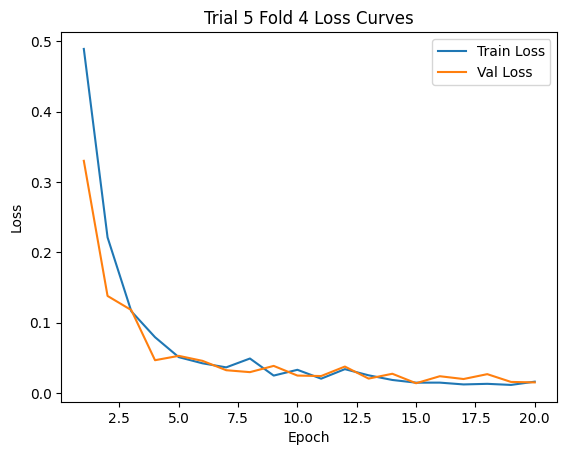

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 5, Epoch 1, Train Loss: 0.4842, Val Loss: 0.3468, F1: 0.4786, Acc: 0.8611
Fold 5, Epoch 2, Train Loss: 0.2885, Val Loss: 0.2016, F1: 0.8345, Acc: 0.9293
Fold 5, Epoch 3, Train Loss: 0.1568, Val Loss: 0.1581, F1: 0.8729, Acc: 0.9469
Fold 5, Epoch 4, Train Loss: 0.0956, Val Loss: 0.0576, F1: 0.9626, Acc: 0.9843
Fold 5, Epoch 5, Train Loss: 0.0694, Val Loss: 0.0475, F1: 0.9708, Acc: 0.9870
Fold 5, Epoch 6, Train Loss: 0.0409, Val Loss: 0.0300, F1: 0.9851, Acc: 0.9935
Fold 5, Epoch 7, Train Loss: 0.0353, Val Loss: 0.0234, F1: 0.9844, Acc: 0.9932
Fold 5, Epoch 8, Train Loss: 0.0411, Val Loss: 0.0307, F1: 0.9840, Acc: 0.9932
Fold 5, Epoch 9, Train Loss: 0.0995, Val Loss: 0.0964, F1: 0.9102, Acc: 0.9642
Fold 5, Epoch 10, Train Loss: 0.0460, Val Loss: 0.0233, F1: 0.9879, Acc: 0.9948
Fold 5, Epoch 11, Train Loss: 0.0201, Val Loss: 0.0201, F1: 0.9860, Acc: 0.9938
Fold 5, Epoch 12, Train Loss: 0.0170, Val Loss: 0.0205, F1: 0.9883, Acc: 0.9951
Fold 5, Epoch 13, Train Loss: 0.0158, Val Loss: 0

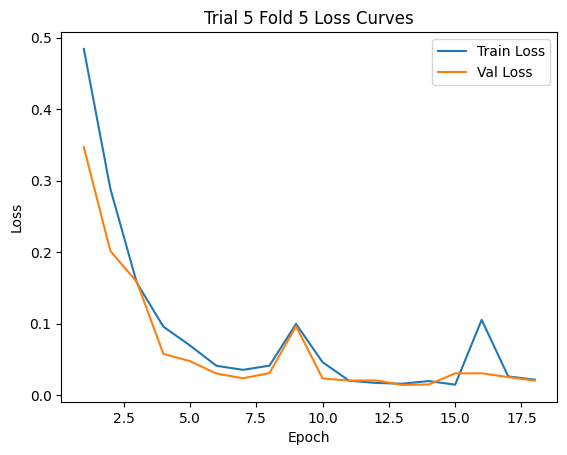

Trial 5 Mean F1: 0.9938

Best Mean F1: 0.996211516311233
Best Hyperparameters: {'batch_size': 32, 'lr': 0.001, 'lstm_hidden': 64, 'tabular_hidden': 16, 'combined_hidden': 64, 'dropout': 0.3, 'bidirectional': True}


In [15]:
sensor_data = X_train_sensor_clipped
tab_data = X_train_tab_scaled
#labels = y_train_multi_df
labels = y_train_multi_df.values.astype(np.float32)

best_params, best_f1, best_model_state = run_random_search_cv(
    sensor_data=sensor_data,
    tab_data=tab_data,
    labels=labels,
    num_trials=5,
    num_epochs=30,
    patience=5,
    device=device
)


In [16]:
import torch
import pickle
from sklearn.metrics import f1_score, accuracy_score, precision_score

# Load best hyperparameters
with open("best_hyperparams.pkl", "rb") as f:
    best_params = pickle.load(f)
print("Best Hyperparameters:", best_params)

# Load best model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = BrakeLSTMModel(
    X_train_tab_scaled.shape[1],
    best_params["lstm_hidden"],
    best_params["tabular_hidden"],
    best_params["combined_hidden"]
).to(device)

model.load_state_dict(torch.load("Multi_label_LSTM.pth"))
model.eval()


Best Hyperparameters: {'batch_size': 32, 'lr': 0.001, 'lstm_hidden': 64, 'tabular_hidden': 16, 'combined_hidden': 64, 'dropout': 0.3, 'bidirectional': True}


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


BrakeLSTMModel(
  (lstm): LSTM(6, 64, batch_first=True, dropout=0.3, bidirectional=True)
  (tab_fc): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=144, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (fc_out): Linear(in_features=64, out_features=4, bias=True)
)

In [ ]:
test_dataset = BrakeDataset(
    X_test_sensor_clipped,
    X_test_tab_scaled,
    y_test_multi_df.values.astype(np.float32)  
)
from torch.utils.data import DataLoader

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

sensor, tab, label = next(iter(test_loader))
print(sensor.shape, tab.shape, label.shape)


torch.Size([64, 128, 6]) torch.Size([64, 3]) torch.Size([64, 4])



=== Evaluation on Test Data ===
Test Loss: 1.4780
Macro F1-score: 0.1600
Micro F1-score: 0.1845
Macro Precision: 0.1286
Micro Precision: 0.1430
Exact Match Ratio (subset accuracy): 0.3656
Hamming Loss: 0.2340

=== Per-label Classification Report ===
              precision    recall  f1-score   support

  front_left       0.02      0.02      0.02       103
 front_right       0.13      0.14      0.13        96
   rear_left       0.20      0.26      0.23       104
  rear_right       0.17      0.61      0.26       105

   micro avg       0.14      0.26      0.18       408
   macro avg       0.13      0.26      0.16       408
weighted avg       0.13      0.26      0.16       408
 samples avg       0.09      0.11      0.09       408

Accuracy for front_left: 0.7762
Accuracy for front_right: 0.8282
Accuracy for rear_left: 0.8172
Accuracy for rear_right: 0.6424


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

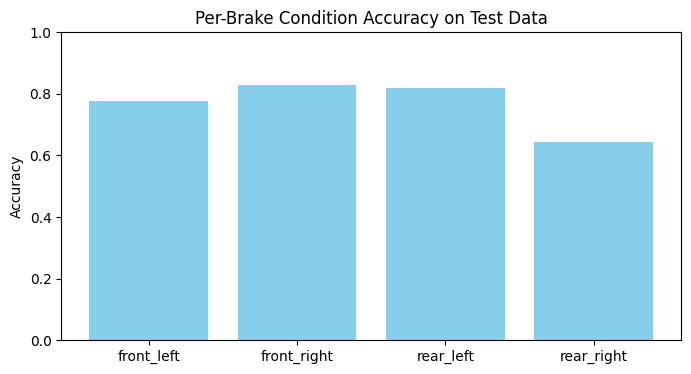

front_left AUC: 0.3463
front_right AUC: 0.6187
rear_left AUC: 0.7216
rear_right AUC: 0.6660


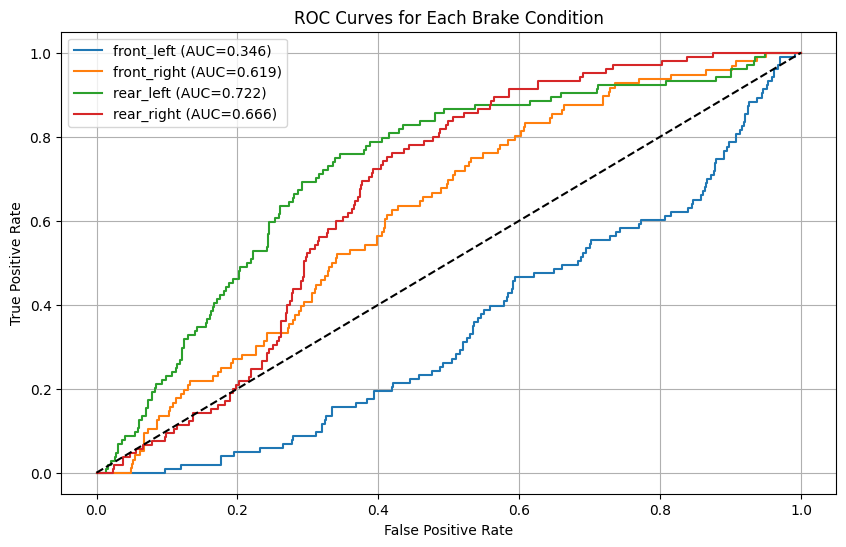

In [18]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, classification_report, hamming_loss
import numpy as np
import torch

# Evaluate model on test data
all_preds, all_labels = [], []
criterion = torch.nn.BCEWithLogitsLoss()

model.eval()
test_loss = 0

with torch.no_grad():
    for sensor, tab, label in test_loader:
        sensor, tab, label = sensor.to(device), tab.to(device), label.to(device)
        outputs = model(sensor, tab)
        loss = criterion(outputs, label)
        test_loss += loss.item() * sensor.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(label.cpu().numpy())

# Aggregate predictions and labels
test_loss /= len(test_loader.dataset)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# Calculate metrics
f1_macro = f1_score(all_labels, all_preds, average="macro")
f1_micro = f1_score(all_labels, all_preds, average="micro")
precision_macro = precision_score(all_labels, all_preds, average="macro")
precision_micro = precision_score(all_labels, all_preds, average="micro")
# Subset accuracy (exact match ratio)
exact_match_acc = np.mean(np.all(all_preds == all_labels, axis=1))
# Hamming loss
hamming = hamming_loss(all_labels, all_preds)

print(f"\n=== Evaluation on Test Data ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Macro F1-score: {f1_macro:.4f}")
print(f"Micro F1-score: {f1_micro:.4f}")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Micro Precision: {precision_micro:.4f}")
print(f"Exact Match Ratio (subset accuracy): {exact_match_acc:.4f}")
print(f"Hamming Loss: {hamming:.4f}")

# Detailed classification report per brake condition
brake_conditions = ["front_left", "front_right", "rear_left", "rear_right"]
print("\n=== Per-label Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=brake_conditions))

# Per-brake accuracy visualization
import matplotlib.pyplot as plt

per_brake_acc = []
for i, brake in enumerate(brake_conditions):
    acc_i = accuracy_score(all_labels[:, i], all_preds[:, i])
    per_brake_acc.append(acc_i)
    print(f"Accuracy for {brake}: {acc_i:.4f}")

plt.figure(figsize=(8, 4))
plt.bar(brake_conditions, per_brake_acc, color='skyblue')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Per-Brake Condition Accuracy on Test Data")
plt.show()

# ROC AUC visualization for each brake
from sklearn.metrics import roc_auc_score, roc_curve

# Get predicted probabilities
all_probs = []
with torch.no_grad():
    for sensor, tab, _ in test_loader:
        sensor, tab = sensor.to(device), tab.to(device)
        outputs = torch.sigmoid(model(sensor, tab)).cpu().numpy()
        all_probs.append(outputs)
all_probs = np.vstack(all_probs)

# Plot ROC curves
plt.figure(figsize=(10, 6))
for i, brake in enumerate(brake_conditions):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    auc = roc_auc_score(all_labels[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"{brake} (AUC={auc:.3f})")
    print(f"{brake} AUC: {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Each Brake Condition")
plt.legend()
plt.grid()
plt.show()


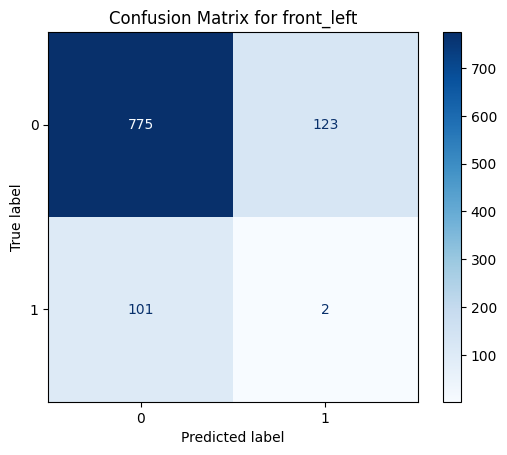

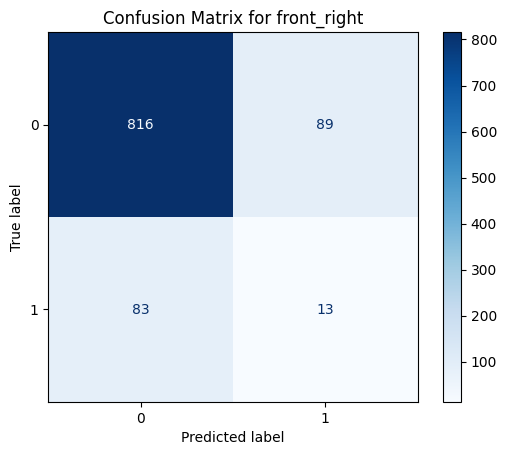

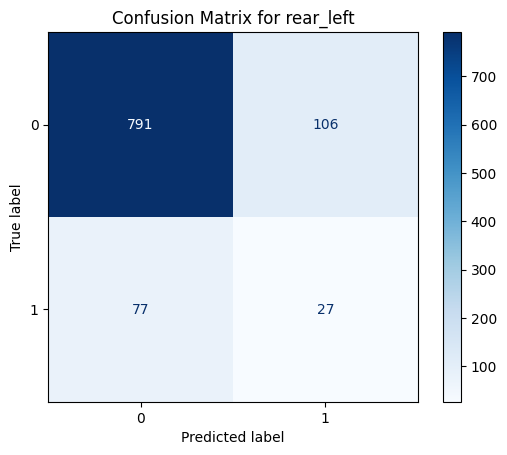

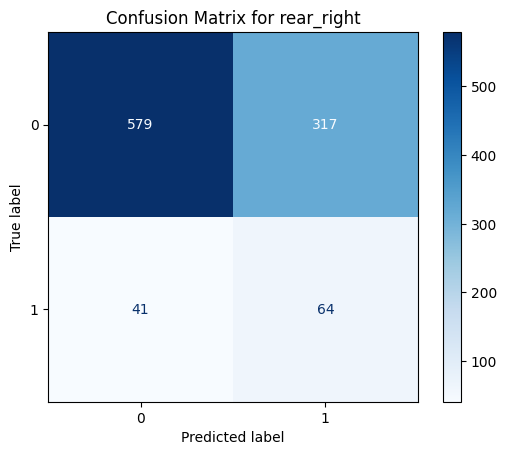

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# brake_conditions defined earlier
# all_labels and all_preds are numpy arrays with shape (num_samples, 4)

for i, brake in enumerate(brake_conditions):
    cm = confusion_matrix(all_labels[:, i], all_preds[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues, values_format="d")
    plt.title(f"Confusion Matrix for {brake}")
    plt.show()


# With class weight in BCEWithLogitsLoss

In [28]:
import os
import pickle
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ----------------------------
# Dataset
# ----------------------------
class BrakeDataset(Dataset):
    def __init__(self, sensor_data, tabular_data, labels):
        self.sensor_data = torch.tensor(sensor_data, dtype=torch.float32)
        self.tabular_data = torch.tensor(tabular_data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sensor_data[idx], self.tabular_data[idx], self.labels[idx]

# ----------------------------
# Model
# ----------------------------
class BrakeLSTMModel(nn.Module):
    def __init__(self, tabular_input_dim, lstm_hidden, tabular_hidden, combined_hidden,
                 dropout=0.3, bidirectional=True):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=6,
            hidden_size=lstm_hidden,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if bidirectional or lstm_hidden > 1 else 0
        )
        lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)

        self.tab_fc = nn.Sequential(
            nn.Linear(tabular_input_dim, tabular_hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.fc1 = nn.Sequential(
            nn.Linear(lstm_out_dim + tabular_hidden, combined_hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.fc_out = nn.Linear(combined_hidden, 4)  # 4 labels for multi-label classification

    def forward(self, sensor_seq, tabular_data):
        lstm_out, _ = self.lstm(sensor_seq)
        lstm_out = lstm_out[:, -1, :]
        tab_out = self.tab_fc(tabular_data)
        combined = torch.cat([lstm_out, tab_out], dim=1)
        x = self.fc1(combined)
        return self.fc_out(x)  # logits

# ----------------------------
# Compute class weights
# ----------------------------
def compute_pos_weights(labels: np.ndarray):
    label_sums = labels.sum(axis=0)
    n_samples = labels.shape[0]
    pos_weight = (n_samples - label_sums) / (label_sums + 1e-5)
    return torch.tensor(pos_weight, dtype=torch.float32).to(device)

# ----------------------------
# Training with Early Stopping + Per-label F1 Tracking
# ----------------------------
def run_random_search_cv(sensor_data, tab_data, labels, num_trials=5, num_epochs=30,
                         patience=5, device='cpu'):
    param_grid = {
        "batch_size": [32, 64],
        "lr": [0.001, 0.0005],
        "lstm_hidden": [32, 64],
        "tabular_hidden": [16, 32],
        "combined_hidden": [32, 64],
        "dropout": [0.1, 0.3],
        "bidirectional": [True, False]
    }

    best_model_path = "Multi_label_classweight_LSTM.pth"
    best_hyperparams_path = "best_hyperparams.pkl"
    best_f1 = 0
    best_params = {}
    best_model_state = None

    full_dataset = BrakeDataset(sensor_data, tab_data, labels)
    pos_weight_tensor = compute_pos_weights(labels)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for trial in range(num_trials):
        params = {k: random.choice(v) for k, v in param_grid.items()}
        print(f"\nTrial {trial+1}, Params: {params}")

        fold_f1s = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(tab_data)):
            train_dataset = Subset(full_dataset, train_idx)
            val_dataset = Subset(full_dataset, val_idx)
            train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=params["batch_size"], shuffle=False)

            model = BrakeLSTMModel(
                tabular_input_dim=tab_data.shape[1],
                lstm_hidden=params["lstm_hidden"],
                tabular_hidden=params["tabular_hidden"],
                combined_hidden=params["combined_hidden"],
                dropout=params["dropout"],
                bidirectional=params["bidirectional"]
            ).to(device)

            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
            optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])

            best_val_f1 = 0
            epochs_no_improve = 0
            train_losses, val_losses = [], []

            for epoch in range(num_epochs):
                model.train()
                total_train_loss = 0
                for sensor, tab, label in train_loader:
                    sensor, tab, label = sensor.to(device), tab.to(device), label.to(device)
                    optimizer.zero_grad()
                    outputs = model(sensor, tab)
                    loss = criterion(outputs, label)
                    loss.backward()
                    optimizer.step()
                    total_train_loss += loss.item() * sensor.size(0)

                avg_train_loss = total_train_loss / len(train_loader.dataset)
                train_losses.append(avg_train_loss)

                model.eval()
                total_val_loss = 0
                all_preds, all_labels = [], []
                with torch.no_grad():
                    for sensor, tab, label in val_loader:
                        sensor, tab, label = sensor.to(device), tab.to(device), label.to(device)
                        outputs = model(sensor, tab)
                        loss = criterion(outputs, label)
                        total_val_loss += loss.item() * sensor.size(0)
                        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
                        all_preds.append(preds)
                        all_labels.append(label.cpu().numpy())

                avg_val_loss = total_val_loss / len(val_loader.dataset)
                val_losses.append(avg_val_loss)

                all_preds = np.vstack(all_preds)
                all_labels = np.vstack(all_labels)
                per_label_f1 = f1_score(all_labels, all_preds, average=None)

                print(f"Fold {fold+1}, Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, "
                      f"Val Loss: {avg_val_loss:.4f}, Per-label F1: {np.round(per_label_f1, 3)}")

                val_f1 = per_label_f1.mean()
                if val_f1 > best_val_f1:
                    best_val_f1 = val_f1
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience:
                        print(f"Early stopping at epoch {epoch+1}")
                        break

            plt.figure()
            plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss")
            plt.plot(range(1, len(val_losses)+1), val_losses, label="Val Loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.title(f"Trial {trial+1} Fold {fold+1} Loss Curves")
            plt.legend()
            plt.show()

            fold_f1s.append(best_val_f1)

        mean_f1 = np.mean(fold_f1s)
        print(f"Trial {trial+1} Mean F1: {mean_f1:.4f}")

        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_params = params.copy()
            best_model_state = model.state_dict()
            torch.save(best_model_state, best_model_path)

    print("\nBest Mean F1:", best_f1)
    print("Best Hyperparameters:", best_params)
    with open(best_hyperparams_path, "wb") as f:
        pickle.dump(best_params, f)

    return best_params, best_f1, best_model_state



Trial 1, Params: {'batch_size': 32, 'lr': 0.0005, 'lstm_hidden': 32, 'tabular_hidden': 32, 'combined_hidden': 32, 'dropout': 0.3, 'bidirectional': False}


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 1, Epoch 1, Train Loss: 1.0445, Val Loss: 0.9603, Per-label F1: [0.482 0.472 0.702 0.37 ]
Fold 1, Epoch 2, Train Loss: 0.8328, Val Loss: 0.6852, Per-label F1: [0.547 0.584 0.834 0.66 ]
Fold 1, Epoch 3, Train Loss: 0.6206, Val Loss: 0.4940, Per-label F1: [0.621 0.697 0.857 0.699]
Fold 1, Epoch 4, Train Loss: 0.4826, Val Loss: 0.3861, Per-label F1: [0.707 0.727 0.896 0.861]
Fold 1, Epoch 5, Train Loss: 0.3851, Val Loss: 0.2978, Per-label F1: [0.828 0.769 0.915 0.901]
Fold 1, Epoch 6, Train Loss: 0.3088, Val Loss: 0.2647, Per-label F1: [0.754 0.774 0.955 0.945]
Fold 1, Epoch 7, Train Loss: 0.2613, Val Loss: 0.2113, Per-label F1: [0.824 0.849 0.961 0.964]
Fold 1, Epoch 8, Train Loss: 0.2500, Val Loss: 0.1876, Per-label F1: [0.83  0.869 0.953 0.95 ]
Fold 1, Epoch 9, Train Loss: 0.2166, Val Loss: 0.1689, Per-label F1: [0.852 0.886 0.955 0.956]
Fold 1, Epoch 10, Train Loss: 0.2105, Val Loss: 0.1579, Per-label F1: [0.85  0.868 0.961 0.97 ]
Fold 1, Epoch 11, Train Loss: 0.1980, Val Loss: 0

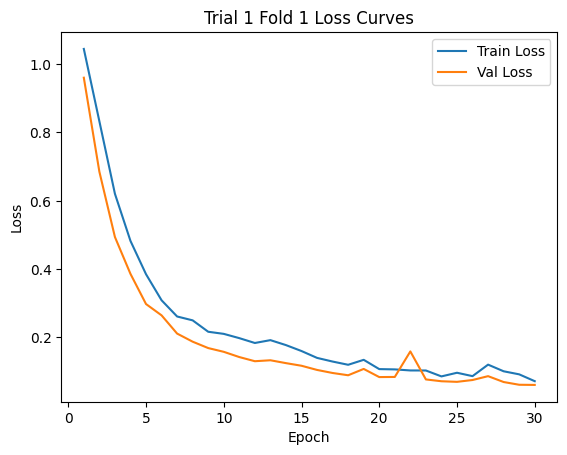

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 2, Epoch 1, Train Loss: 1.0340, Val Loss: 0.9319, Per-label F1: [0.516 0.552 0.512 0.537]
Fold 2, Epoch 2, Train Loss: 0.8216, Val Loss: 0.6316, Per-label F1: [0.687 0.638 0.682 0.788]
Fold 2, Epoch 3, Train Loss: 0.5644, Val Loss: 0.4049, Per-label F1: [0.829 0.713 0.834 0.861]
Fold 2, Epoch 4, Train Loss: 0.4168, Val Loss: 0.3061, Per-label F1: [0.806 0.802 0.826 0.861]
Fold 2, Epoch 5, Train Loss: 0.3418, Val Loss: 0.2546, Per-label F1: [0.822 0.849 0.832 0.86 ]
Fold 2, Epoch 6, Train Loss: 0.3039, Val Loss: 0.2228, Per-label F1: [0.825 0.854 0.847 0.87 ]
Fold 2, Epoch 7, Train Loss: 0.2832, Val Loss: 0.2091, Per-label F1: [0.843 0.87  0.851 0.855]
Fold 2, Epoch 8, Train Loss: 0.2580, Val Loss: 0.1867, Per-label F1: [0.873 0.897 0.833 0.851]
Fold 2, Epoch 9, Train Loss: 0.2262, Val Loss: 0.1629, Per-label F1: [0.893 0.885 0.862 0.878]
Fold 2, Epoch 10, Train Loss: 0.2213, Val Loss: 0.1502, Per-label F1: [0.909 0.909 0.873 0.875]
Fold 2, Epoch 11, Train Loss: 0.1851, Val Loss: 0

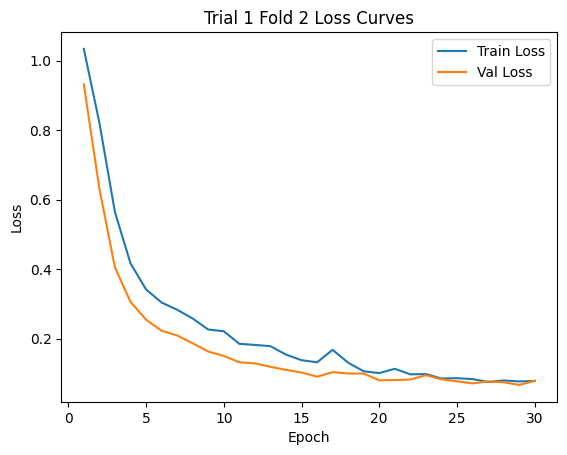

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 3, Epoch 1, Train Loss: 1.0176, Val Loss: 0.9066, Per-label F1: [0.421 0.397 0.641 0.459]
Fold 3, Epoch 2, Train Loss: 0.8067, Val Loss: 0.6801, Per-label F1: [0.535 0.554 0.819 0.67 ]
Fold 3, Epoch 3, Train Loss: 0.6304, Val Loss: 0.5136, Per-label F1: [0.598 0.64  0.868 0.715]
Fold 3, Epoch 4, Train Loss: 0.4906, Val Loss: 0.4005, Per-label F1: [0.677 0.718 0.859 0.822]
Fold 3, Epoch 5, Train Loss: 0.4047, Val Loss: 0.3322, Per-label F1: [0.705 0.777 0.891 0.836]
Fold 3, Epoch 6, Train Loss: 0.3537, Val Loss: 0.3141, Per-label F1: [0.755 0.756 0.899 0.841]
Fold 3, Epoch 7, Train Loss: 0.3060, Val Loss: 0.2558, Per-label F1: [0.757 0.802 0.95  0.881]
Fold 3, Epoch 8, Train Loss: 0.2804, Val Loss: 0.2294, Per-label F1: [0.789 0.823 0.955 0.899]
Fold 3, Epoch 9, Train Loss: 0.2464, Val Loss: 0.2206, Per-label F1: [0.833 0.803 0.94  0.945]
Fold 3, Epoch 10, Train Loss: 0.2218, Val Loss: 0.1698, Per-label F1: [0.828 0.835 0.974 0.972]
Fold 3, Epoch 11, Train Loss: 0.1934, Val Loss: 0

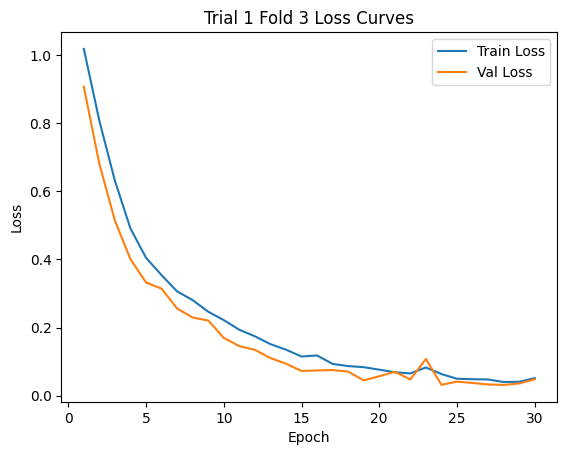

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 4, Epoch 1, Train Loss: 1.0323, Val Loss: 0.9518, Per-label F1: [0.57  0.529 0.63  0.498]
Fold 4, Epoch 2, Train Loss: 0.8239, Val Loss: 0.6734, Per-label F1: [0.732 0.735 0.655 0.703]
Fold 4, Epoch 3, Train Loss: 0.5613, Val Loss: 0.4291, Per-label F1: [0.754 0.814 0.803 0.864]
Fold 4, Epoch 4, Train Loss: 0.4127, Val Loss: 0.3078, Per-label F1: [0.833 0.819 0.851 0.942]
Fold 4, Epoch 5, Train Loss: 0.3142, Val Loss: 0.2435, Per-label F1: [0.845 0.853 0.916 0.966]
Fold 4, Epoch 6, Train Loss: 0.2581, Val Loss: 0.1893, Per-label F1: [0.858 0.87  0.938 0.969]
Fold 4, Epoch 7, Train Loss: 0.2055, Val Loss: 0.1615, Per-label F1: [0.886 0.887 0.969 0.966]
Fold 4, Epoch 8, Train Loss: 0.1790, Val Loss: 0.1246, Per-label F1: [0.935 0.94  0.979 0.964]
Fold 4, Epoch 9, Train Loss: 0.1613, Val Loss: 0.1044, Per-label F1: [0.976 0.932 0.993 0.979]
Fold 4, Epoch 10, Train Loss: 0.1335, Val Loss: 0.1204, Per-label F1: [0.935 0.964 0.99  0.974]
Fold 4, Epoch 11, Train Loss: 0.1276, Val Loss: 0

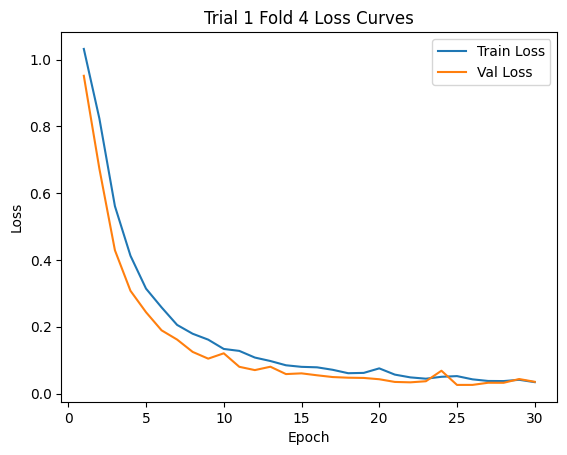

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Fold 5, Epoch 1, Train Loss: 1.0467, Val Loss: 0.9298, Per-label F1: [0.464 0.489 0.55  0.463]
Fold 5, Epoch 2, Train Loss: 0.8762, Val Loss: 0.7708, Per-label F1: [0.478 0.584 0.756 0.545]
Fold 5, Epoch 3, Train Loss: 0.6887, Val Loss: 0.5483, Per-label F1: [0.603 0.708 0.811 0.853]
Fold 5, Epoch 4, Train Loss: 0.5009, Val Loss: 0.3785, Per-label F1: [0.716 0.76  0.85  0.915]
Fold 5, Epoch 5, Train Loss: 0.3697, Val Loss: 0.2639, Per-label F1: [0.741 0.846 0.933 0.95 ]
Fold 5, Epoch 6, Train Loss: 0.2730, Val Loss: 0.2037, Per-label F1: [0.82  0.862 0.955 0.955]
Fold 5, Epoch 7, Train Loss: 0.2282, Val Loss: 0.1612, Per-label F1: [0.885 0.87  0.97  0.968]
Fold 5, Epoch 8, Train Loss: 0.1853, Val Loss: 0.1247, Per-label F1: [0.93  0.944 0.973 0.976]
Fold 5, Epoch 9, Train Loss: 0.1664, Val Loss: 0.1159, Per-label F1: [0.978 0.936 0.97  0.995]
Fold 5, Epoch 10, Train Loss: 0.1668, Val Loss: 0.0953, Per-label F1: [0.981 0.934 0.97  0.973]
Fold 5, Epoch 11, Train Loss: 0.1208, Val Loss: 0

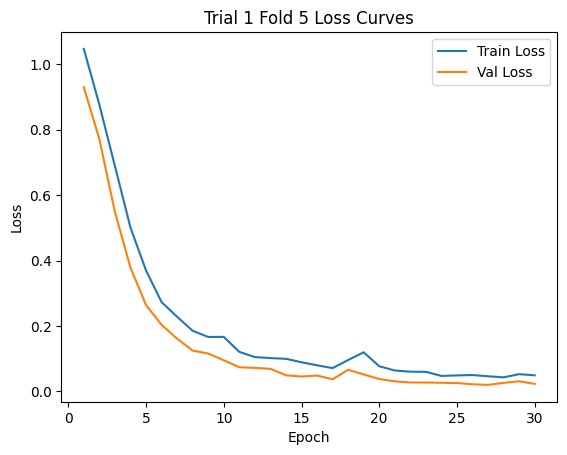

Trial 1 Mean F1: 0.9873

Trial 2, Params: {'batch_size': 32, 'lr': 0.001, 'lstm_hidden': 32, 'tabular_hidden': 16, 'combined_hidden': 64, 'dropout': 0.1, 'bidirectional': True}


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 1, Epoch 1, Train Loss: 0.9220, Val Loss: 0.6551, Per-label F1: [0.652 0.695 0.768 0.547]
Fold 1, Epoch 2, Train Loss: 0.4405, Val Loss: 0.2874, Per-label F1: [0.793 0.872 0.89  0.852]
Fold 1, Epoch 3, Train Loss: 0.2437, Val Loss: 0.1686, Per-label F1: [0.847 0.91  0.927 0.863]
Fold 1, Epoch 4, Train Loss: 0.1557, Val Loss: 0.0995, Per-label F1: [0.971 0.973 0.926 0.942]
Fold 1, Epoch 5, Train Loss: 0.1034, Val Loss: 0.0621, Per-label F1: [0.983 0.975 0.983 0.988]
Fold 1, Epoch 6, Train Loss: 0.0625, Val Loss: 0.0745, Per-label F1: [0.967 0.989 0.976 0.982]
Fold 1, Epoch 7, Train Loss: 0.0463, Val Loss: 0.0412, Per-label F1: [0.988 0.981 0.985 0.985]
Fold 1, Epoch 8, Train Loss: 0.0379, Val Loss: 0.0358, Per-label F1: [0.977 0.978 0.99  0.985]
Fold 1, Epoch 9, Train Loss: 0.0294, Val Loss: 0.0332, Per-label F1: [0.977 0.989 0.99  0.985]
Fold 1, Epoch 10, Train Loss: 0.0211, Val Loss: 0.0298, Per-label F1: [0.985 1.    0.993 0.991]
Fold 1, Epoch 11, Train Loss: 0.0321, Val Loss: 0

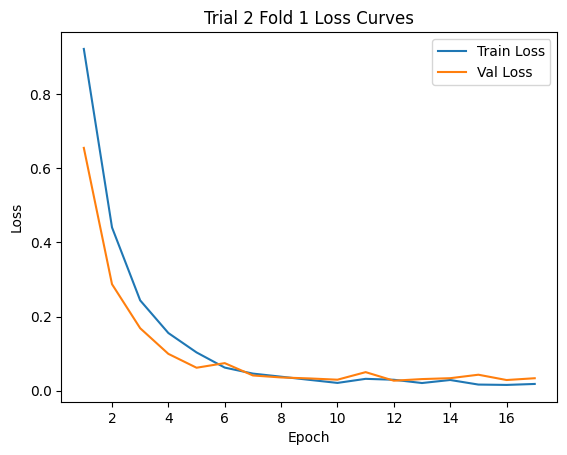

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 2, Epoch 1, Train Loss: 0.9224, Val Loss: 0.6502, Per-label F1: [0.538 0.667 0.796 0.777]
Fold 2, Epoch 2, Train Loss: 0.4627, Val Loss: 0.2863, Per-label F1: [0.689 0.873 0.856 0.843]
Fold 2, Epoch 3, Train Loss: 0.2454, Val Loss: 0.1889, Per-label F1: [0.893 0.974 0.851 0.87 ]
Fold 2, Epoch 4, Train Loss: 0.1451, Val Loss: 0.1082, Per-label F1: [0.953 0.997 0.914 0.941]
Fold 2, Epoch 5, Train Loss: 0.0952, Val Loss: 0.0682, Per-label F1: [0.979 0.992 0.951 0.977]
Fold 2, Epoch 6, Train Loss: 0.0672, Val Loss: 0.0556, Per-label F1: [0.981 0.99  0.976 0.979]
Fold 2, Epoch 7, Train Loss: 0.0465, Val Loss: 0.0391, Per-label F1: [0.995 0.992 0.976 0.982]
Fold 2, Epoch 8, Train Loss: 0.0693, Val Loss: 0.0329, Per-label F1: [0.989 0.992 0.979 0.988]
Fold 2, Epoch 9, Train Loss: 0.0336, Val Loss: 0.0341, Per-label F1: [0.992 0.987 0.982 0.985]
Fold 2, Epoch 10, Train Loss: 0.0315, Val Loss: 0.0333, Per-label F1: [0.982 0.995 0.985 0.985]
Fold 2, Epoch 11, Train Loss: 0.0343, Val Loss: 0

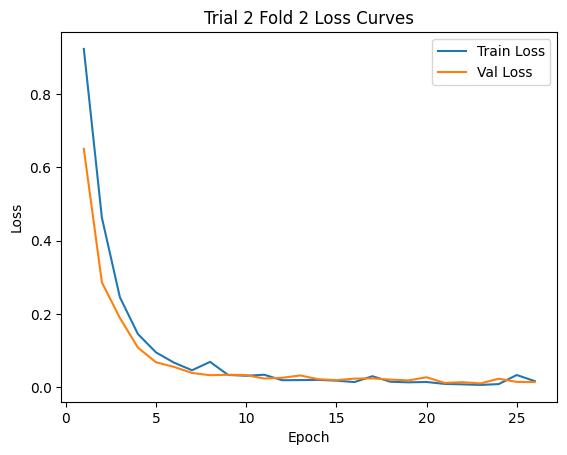

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 3, Epoch 1, Train Loss: 0.9237, Val Loss: 0.7264, Per-label F1: [0.59  0.557 0.674 0.693]
Fold 3, Epoch 2, Train Loss: 0.5101, Val Loss: 0.3151, Per-label F1: [0.87  0.866 0.842 0.81 ]
Fold 3, Epoch 3, Train Loss: 0.2439, Val Loss: 0.1822, Per-label F1: [0.953 0.894 0.865 0.859]
Fold 3, Epoch 4, Train Loss: 0.1352, Val Loss: 0.1058, Per-label F1: [0.971 0.969 0.963 0.966]
Fold 3, Epoch 5, Train Loss: 0.1138, Val Loss: 0.0712, Per-label F1: [0.971 0.98  0.973 0.986]
Fold 3, Epoch 6, Train Loss: 0.0669, Val Loss: 0.0543, Per-label F1: [0.983 0.986 0.984 0.994]
Fold 3, Epoch 7, Train Loss: 0.0522, Val Loss: 0.0557, Per-label F1: [0.974 0.966 0.984 0.992]
Fold 3, Epoch 8, Train Loss: 0.0479, Val Loss: 0.0444, Per-label F1: [0.977 0.991 0.987 0.992]
Fold 3, Epoch 9, Train Loss: 0.0433, Val Loss: 0.0368, Per-label F1: [0.983 0.989 0.987 0.994]
Fold 3, Epoch 10, Train Loss: 0.0347, Val Loss: 0.0427, Per-label F1: [0.988 0.983 0.984 0.989]
Fold 3, Epoch 11, Train Loss: 0.0345, Val Loss: 0

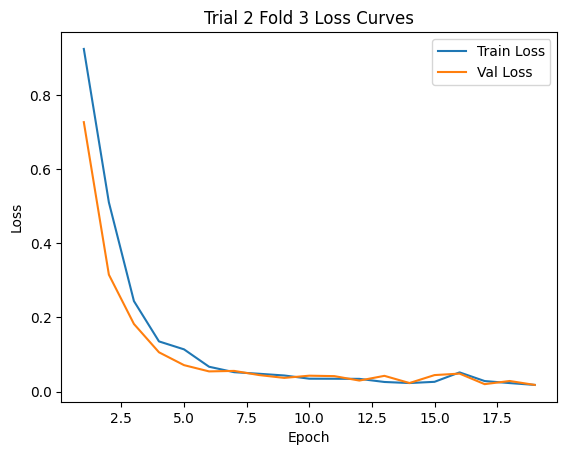

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 4, Epoch 1, Train Loss: 0.8997, Val Loss: 0.6568, Per-label F1: [0.682 0.694 0.757 0.751]
Fold 4, Epoch 2, Train Loss: 0.4188, Val Loss: 0.2508, Per-label F1: [0.879 0.862 0.855 0.873]
Fold 4, Epoch 3, Train Loss: 0.1966, Val Loss: 0.1309, Per-label F1: [0.946 0.958 0.92  0.964]
Fold 4, Epoch 4, Train Loss: 0.1300, Val Loss: 0.0749, Per-label F1: [0.979 0.989 0.96  0.992]
Fold 4, Epoch 5, Train Loss: 0.0834, Val Loss: 0.0583, Per-label F1: [0.964 0.991 0.981 0.992]
Fold 4, Epoch 6, Train Loss: 0.0601, Val Loss: 0.0433, Per-label F1: [0.987 0.989 0.983 0.995]
Fold 4, Epoch 7, Train Loss: 0.0444, Val Loss: 0.0374, Per-label F1: [0.995 0.991 0.991 0.992]
Fold 4, Epoch 8, Train Loss: 0.0384, Val Loss: 0.0374, Per-label F1: [0.989 0.989 0.99  0.995]
Fold 4, Epoch 9, Train Loss: 0.0359, Val Loss: 0.0347, Per-label F1: [0.997 0.989 0.99  0.995]
Fold 4, Epoch 10, Train Loss: 0.0475, Val Loss: 0.0637, Per-label F1: [0.961 0.983 0.979 0.995]
Fold 4, Epoch 11, Train Loss: 0.0426, Val Loss: 0

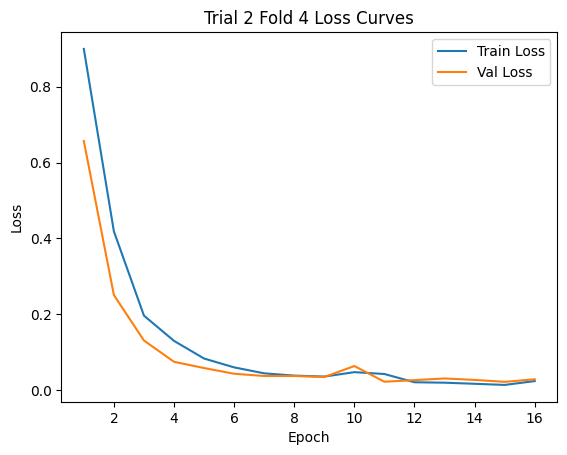

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 5, Epoch 1, Train Loss: 0.8925, Val Loss: 0.5756, Per-label F1: [0.709 0.691 0.727 0.664]
Fold 5, Epoch 2, Train Loss: 0.3654, Val Loss: 0.2454, Per-label F1: [0.859 0.839 0.812 0.829]
Fold 5, Epoch 3, Train Loss: 0.1913, Val Loss: 0.1886, Per-label F1: [0.874 0.875 0.885 0.945]
Fold 5, Epoch 4, Train Loss: 0.1157, Val Loss: 0.0922, Per-label F1: [0.976 0.959 0.953 0.971]
Fold 5, Epoch 5, Train Loss: 0.0738, Val Loss: 0.0635, Per-label F1: [0.968 0.973 0.97  0.966]
Fold 5, Epoch 6, Train Loss: 0.0734, Val Loss: 0.0620, Per-label F1: [0.986 0.934 0.964 0.984]
Fold 5, Epoch 7, Train Loss: 0.0450, Val Loss: 0.0493, Per-label F1: [0.976 0.951 0.988 0.986]
Fold 5, Epoch 8, Train Loss: 0.0350, Val Loss: 0.0271, Per-label F1: [0.989 0.994 0.988 0.989]
Fold 5, Epoch 9, Train Loss: 0.0348, Val Loss: 0.0256, Per-label F1: [0.984 0.994 0.988 0.992]
Fold 5, Epoch 10, Train Loss: 0.0310, Val Loss: 0.0261, Per-label F1: [0.989 0.994 0.988 0.986]
Fold 5, Epoch 11, Train Loss: 0.0239, Val Loss: 0

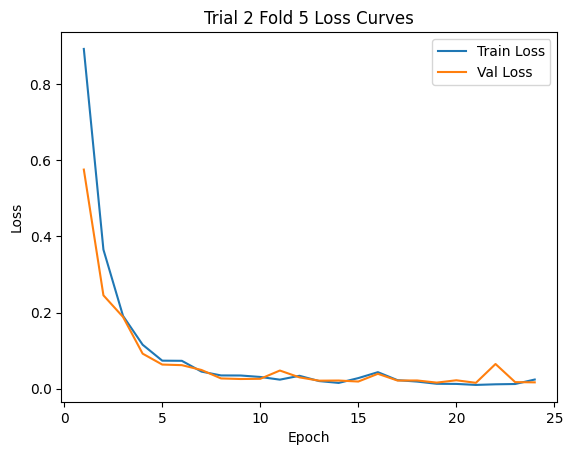

Trial 2 Mean F1: 0.9948

Trial 3, Params: {'batch_size': 32, 'lr': 0.0005, 'lstm_hidden': 64, 'tabular_hidden': 32, 'combined_hidden': 64, 'dropout': 0.1, 'bidirectional': False}


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 1, Epoch 1, Train Loss: 0.9656, Val Loss: 0.7910, Per-label F1: [0.548 0.51  0.721 0.61 ]
Fold 1, Epoch 2, Train Loss: 0.6024, Val Loss: 0.4561, Per-label F1: [0.808 0.656 0.848 0.83 ]
Fold 1, Epoch 3, Train Loss: 0.3804, Val Loss: 0.3000, Per-label F1: [0.806 0.728 0.868 0.866]
Fold 1, Epoch 4, Train Loss: 0.2901, Val Loss: 0.2368, Per-label F1: [0.808 0.84  0.886 0.918]
Fold 1, Epoch 5, Train Loss: 0.2339, Val Loss: 0.1845, Per-label F1: [0.856 0.887 0.904 0.937]
Fold 1, Epoch 6, Train Loss: 0.1908, Val Loss: 0.1565, Per-label F1: [0.901 0.944 0.925 0.967]
Fold 1, Epoch 7, Train Loss: 0.1583, Val Loss: 0.1284, Per-label F1: [0.921 0.944 0.949 0.97 ]
Fold 1, Epoch 8, Train Loss: 0.1445, Val Loss: 0.1188, Per-label F1: [0.918 0.932 0.952 0.97 ]
Fold 1, Epoch 9, Train Loss: 0.1112, Val Loss: 0.0933, Per-label F1: [0.936 0.978 0.968 0.976]
Fold 1, Epoch 10, Train Loss: 0.0973, Val Loss: 0.0847, Per-label F1: [0.94  0.973 0.973 0.982]
Fold 1, Epoch 11, Train Loss: 0.0854, Val Loss: 0

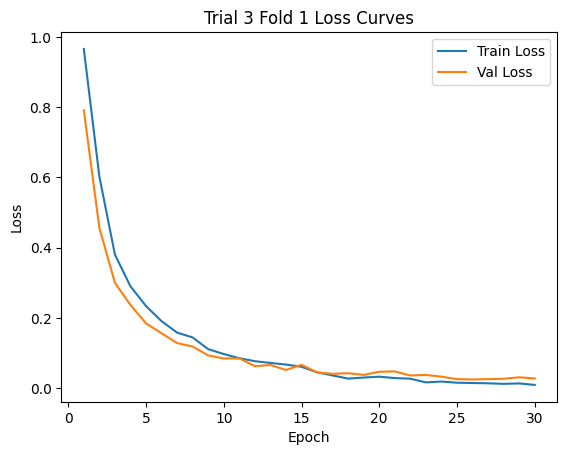

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 2, Epoch 1, Train Loss: 0.9678, Val Loss: 0.7864, Per-label F1: [0.472 0.595 0.734 0.592]
Fold 2, Epoch 2, Train Loss: 0.6429, Val Loss: 0.3907, Per-label F1: [0.714 0.798 0.842 0.804]
Fold 2, Epoch 3, Train Loss: 0.3065, Val Loss: 0.2833, Per-label F1: [0.858 0.861 0.846 0.813]
Fold 2, Epoch 4, Train Loss: 0.2175, Val Loss: 0.1401, Per-label F1: [0.941 0.898 0.973 0.938]
Fold 2, Epoch 5, Train Loss: 0.1300, Val Loss: 0.1000, Per-label F1: [0.96  0.932 0.959 0.965]
Fold 2, Epoch 6, Train Loss: 0.0917, Val Loss: 0.1122, Per-label F1: [0.929 0.959 0.985 0.946]
Fold 2, Epoch 7, Train Loss: 0.0723, Val Loss: 0.0588, Per-label F1: [0.963 0.972 0.985 0.982]
Fold 2, Epoch 8, Train Loss: 0.0574, Val Loss: 0.0518, Per-label F1: [0.963 0.977 0.985 0.982]
Fold 2, Epoch 9, Train Loss: 0.0486, Val Loss: 0.0575, Per-label F1: [0.974 0.987 0.973 0.968]
Fold 2, Epoch 10, Train Loss: 0.0471, Val Loss: 0.0453, Per-label F1: [0.969 0.979 0.979 0.988]
Fold 2, Epoch 11, Train Loss: 0.0447, Val Loss: 0

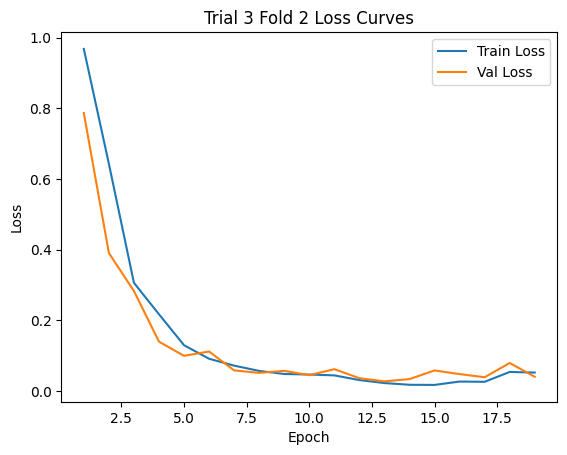

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 3, Epoch 1, Train Loss: 0.9418, Val Loss: 0.7405, Per-label F1: [0.423 0.422 0.75  0.676]
Fold 3, Epoch 2, Train Loss: 0.5827, Val Loss: 0.4364, Per-label F1: [0.637 0.62  0.826 0.83 ]
Fold 3, Epoch 3, Train Loss: 0.3323, Val Loss: 0.2457, Per-label F1: [0.866 0.837 0.844 0.886]
Fold 3, Epoch 4, Train Loss: 0.2044, Val Loss: 0.1699, Per-label F1: [0.926 0.9   0.901 0.926]
Fold 3, Epoch 5, Train Loss: 0.1519, Val Loss: 0.1180, Per-label F1: [0.957 0.942 0.956 0.964]
Fold 3, Epoch 6, Train Loss: 0.1088, Val Loss: 0.0827, Per-label F1: [0.982 0.968 0.978 0.992]
Fold 3, Epoch 7, Train Loss: 0.0724, Val Loss: 0.0646, Per-label F1: [0.98  0.973 0.984 0.992]
Fold 3, Epoch 8, Train Loss: 0.0561, Val Loss: 0.0456, Per-label F1: [0.983 0.977 0.992 0.992]
Fold 3, Epoch 9, Train Loss: 0.0639, Val Loss: 0.0693, Per-label F1: [0.977 0.958 0.979 0.992]
Fold 3, Epoch 10, Train Loss: 0.0510, Val Loss: 0.0559, Per-label F1: [0.985 0.98  0.989 0.992]
Fold 3, Epoch 11, Train Loss: 0.0383, Val Loss: 0

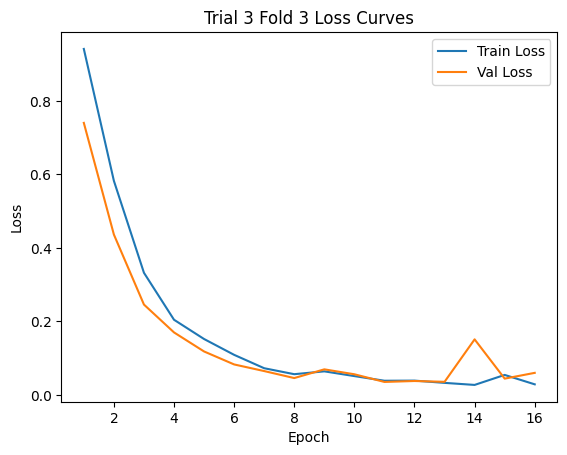

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 4, Epoch 1, Train Loss: 0.9551, Val Loss: 0.7798, Per-label F1: [0.486 0.343 0.791 0.705]
Fold 4, Epoch 2, Train Loss: 0.6046, Val Loss: 0.4249, Per-label F1: [0.842 0.652 0.928 0.87 ]
Fold 4, Epoch 3, Train Loss: 0.2957, Val Loss: 0.2436, Per-label F1: [0.931 0.781 0.904 0.936]
Fold 4, Epoch 4, Train Loss: 0.1668, Val Loss: 0.1338, Per-label F1: [0.925 0.902 0.976 0.974]
Fold 4, Epoch 5, Train Loss: 0.1182, Val Loss: 0.0890, Per-label F1: [0.963 0.959 0.986 0.99 ]
Fold 4, Epoch 6, Train Loss: 0.0861, Val Loss: 0.0703, Per-label F1: [0.961 0.946 0.986 0.987]
Fold 4, Epoch 7, Train Loss: 0.0681, Val Loss: 0.0615, Per-label F1: [0.978 0.98  0.99  0.99 ]
Fold 4, Epoch 8, Train Loss: 0.0561, Val Loss: 0.0424, Per-label F1: [0.982 0.977 0.986 0.992]
Fold 4, Epoch 9, Train Loss: 0.0553, Val Loss: 0.0408, Per-label F1: [0.982 0.989 0.993 0.992]
Fold 4, Epoch 10, Train Loss: 0.0460, Val Loss: 0.0471, Per-label F1: [0.976 0.971 0.995 0.99 ]
Fold 4, Epoch 11, Train Loss: 0.0429, Val Loss: 0

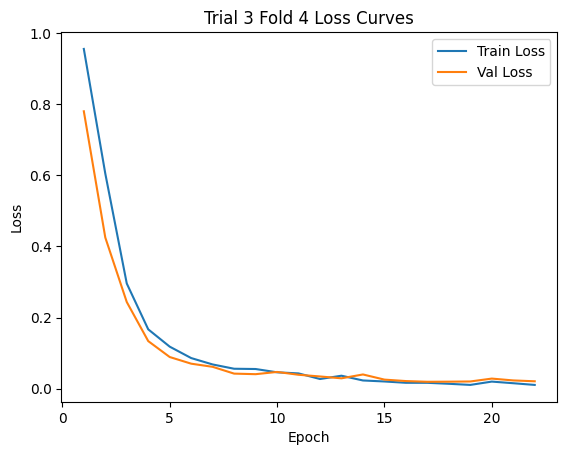

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 5, Epoch 1, Train Loss: 0.9652, Val Loss: 0.7880, Per-label F1: [0.477 0.57  0.677 0.66 ]
Fold 5, Epoch 2, Train Loss: 0.5964, Val Loss: 0.4021, Per-label F1: [0.675 0.708 0.767 0.823]
Fold 5, Epoch 3, Train Loss: 0.3004, Val Loss: 0.2156, Per-label F1: [0.885 0.967 0.807 0.859]
Fold 5, Epoch 4, Train Loss: 0.1618, Val Loss: 0.1250, Per-label F1: [0.966 0.942 0.883 0.954]
Fold 5, Epoch 5, Train Loss: 0.0978, Val Loss: 0.0832, Per-label F1: [0.948 0.967 0.955 0.958]
Fold 5, Epoch 6, Train Loss: 0.0640, Val Loss: 0.1430, Per-label F1: [0.964 0.94  0.964 0.992]
Fold 5, Epoch 7, Train Loss: 0.0615, Val Loss: 0.0608, Per-label F1: [0.966 0.948 0.982 0.989]
Fold 5, Epoch 8, Train Loss: 0.0432, Val Loss: 0.0451, Per-label F1: [0.987 0.967 0.985 0.995]
Fold 5, Epoch 9, Train Loss: 0.0334, Val Loss: 0.0345, Per-label F1: [0.987 0.991 0.982 0.995]
Fold 5, Epoch 10, Train Loss: 0.0240, Val Loss: 0.0365, Per-label F1: [0.989 0.988 0.982 0.995]
Fold 5, Epoch 11, Train Loss: 0.0410, Val Loss: 0

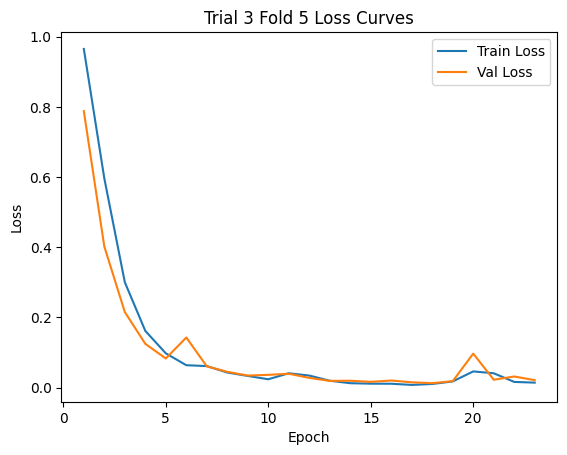

Trial 3 Mean F1: 0.9924

Trial 4, Params: {'batch_size': 64, 'lr': 0.001, 'lstm_hidden': 64, 'tabular_hidden': 16, 'combined_hidden': 32, 'dropout': 0.1, 'bidirectional': True}


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 1, Epoch 1, Train Loss: 0.9985, Val Loss: 0.8616, Per-label F1: [0.418 0.423 0.695 0.53 ]
Fold 1, Epoch 2, Train Loss: 0.7009, Val Loss: 0.5232, Per-label F1: [0.605 0.582 0.913 0.789]
Fold 1, Epoch 3, Train Loss: 0.3748, Val Loss: 0.2257, Per-label F1: [0.888 0.758 0.964 0.982]
Fold 1, Epoch 4, Train Loss: 0.4764, Val Loss: 0.3160, Per-label F1: [0.804 0.843 0.842 0.772]
Fold 1, Epoch 5, Train Loss: 0.2682, Val Loss: 0.1928, Per-label F1: [0.881 0.866 0.895 0.86 ]
Fold 1, Epoch 6, Train Loss: 0.1862, Val Loss: 0.1501, Per-label F1: [0.887 0.897 0.939 0.896]
Fold 1, Epoch 7, Train Loss: 0.1439, Val Loss: 0.1180, Per-label F1: [0.925 0.947 0.943 0.921]
Fold 1, Epoch 8, Train Loss: 0.1353, Val Loss: 0.1087, Per-label F1: [0.938 0.97  0.959 0.921]
Fold 1, Epoch 9, Train Loss: 0.1008, Val Loss: 0.0816, Per-label F1: [0.977 0.97  0.957 0.967]
Fold 1, Epoch 10, Train Loss: 0.0791, Val Loss: 0.0698, Per-label F1: [0.969 0.978 0.985 0.985]
Fold 1, Epoch 11, Train Loss: 0.0621, Val Loss: 0

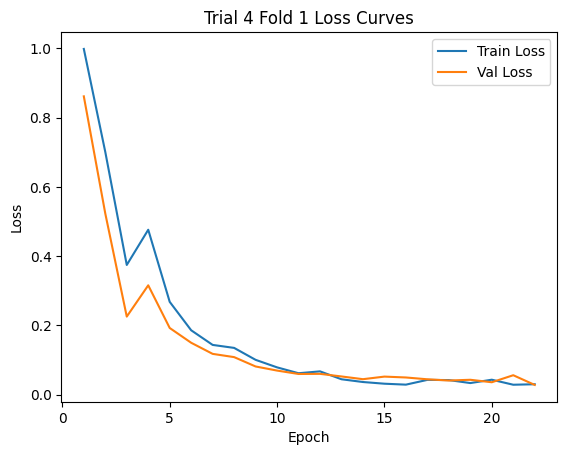

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 2, Epoch 1, Train Loss: 0.9782, Val Loss: 0.7583, Per-label F1: [0.494 0.55  0.814 0.707]
Fold 2, Epoch 2, Train Loss: 0.6388, Val Loss: 0.4753, Per-label F1: [0.624 0.736 0.925 0.898]
Fold 2, Epoch 3, Train Loss: 0.4256, Val Loss: 0.2958, Per-label F1: [0.728 0.829 0.933 0.935]
Fold 2, Epoch 4, Train Loss: 0.2772, Val Loss: 0.1939, Per-label F1: [0.855 0.903 0.961 0.967]
Fold 2, Epoch 5, Train Loss: 0.2176, Val Loss: 0.1504, Per-label F1: [0.901 0.91  0.964 0.976]
Fold 2, Epoch 6, Train Loss: 0.1687, Val Loss: 0.1400, Per-label F1: [0.893 0.866 0.943 0.941]
Fold 2, Epoch 7, Train Loss: 0.1887, Val Loss: 0.1180, Per-label F1: [0.919 0.933 0.943 0.94 ]
Fold 2, Epoch 8, Train Loss: 0.1583, Val Loss: 0.0844, Per-label F1: [0.938 0.955 0.967 0.971]
Fold 2, Epoch 9, Train Loss: 0.1065, Val Loss: 0.0704, Per-label F1: [0.933 0.962 0.968 0.971]
Fold 2, Epoch 10, Train Loss: 0.0827, Val Loss: 0.0570, Per-label F1: [0.969 0.99  0.971 0.968]
Fold 2, Epoch 11, Train Loss: 0.0752, Val Loss: 0

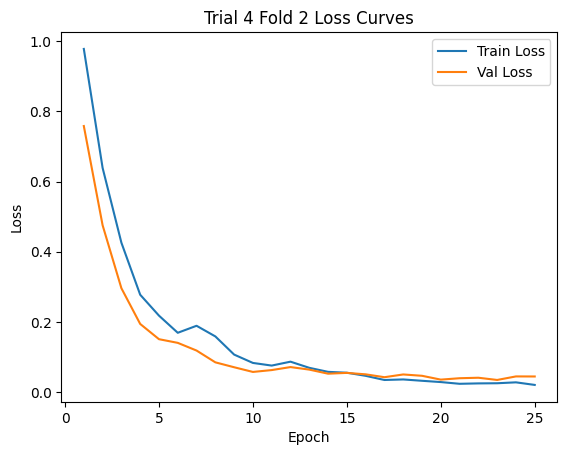

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 3, Epoch 1, Train Loss: 0.9876, Val Loss: 0.8164, Per-label F1: [0.607 0.536 0.537 0.6  ]
Fold 3, Epoch 2, Train Loss: 0.6445, Val Loss: 0.4814, Per-label F1: [0.705 0.668 0.772 0.824]
Fold 3, Epoch 3, Train Loss: 0.3650, Val Loss: 0.2769, Per-label F1: [0.815 0.846 0.841 0.85 ]
Fold 3, Epoch 4, Train Loss: 0.2200, Val Loss: 0.1462, Per-label F1: [0.885 0.927 0.96  0.962]
Fold 3, Epoch 5, Train Loss: 0.1263, Val Loss: 0.0925, Per-label F1: [0.947 0.968 0.957 0.989]
Fold 3, Epoch 6, Train Loss: 0.1045, Val Loss: 0.0750, Per-label F1: [0.944 0.983 0.971 0.989]
Fold 3, Epoch 7, Train Loss: 0.0760, Val Loss: 0.1133, Per-label F1: [0.847 0.955 0.949 0.959]
Fold 3, Epoch 8, Train Loss: 0.1004, Val Loss: 0.0572, Per-label F1: [0.986 0.964 0.989 0.992]
Fold 3, Epoch 9, Train Loss: 0.0496, Val Loss: 0.0376, Per-label F1: [0.991 0.989 0.987 0.992]
Fold 3, Epoch 10, Train Loss: 0.0483, Val Loss: 0.0337, Per-label F1: [0.991 0.975 0.984 0.992]
Fold 3, Epoch 11, Train Loss: 0.0364, Val Loss: 0

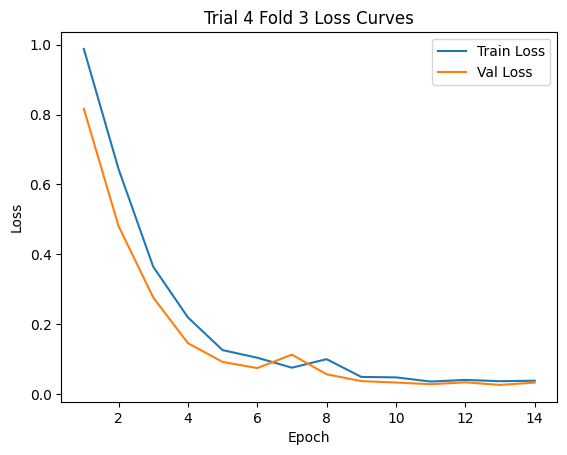

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 4, Epoch 1, Train Loss: 0.9744, Val Loss: 0.8486, Per-label F1: [0.474 0.467 0.728 0.634]
Fold 4, Epoch 2, Train Loss: 0.6981, Val Loss: 0.5372, Per-label F1: [0.605 0.692 0.927 0.884]
Fold 4, Epoch 3, Train Loss: 0.4309, Val Loss: 0.3070, Per-label F1: [0.74  0.831 0.943 0.987]
Fold 4, Epoch 4, Train Loss: 0.2491, Val Loss: 0.1921, Per-label F1: [0.875 0.831 0.947 0.982]
Fold 4, Epoch 5, Train Loss: 0.1679, Val Loss: 0.1444, Per-label F1: [0.888 0.969 0.974 0.989]
Fold 4, Epoch 6, Train Loss: 0.1262, Val Loss: 0.0899, Per-label F1: [0.927 0.975 0.972 0.997]
Fold 4, Epoch 7, Train Loss: 0.0946, Val Loss: 0.0748, Per-label F1: [0.966 0.953 0.983 0.995]
Fold 4, Epoch 8, Train Loss: 0.0732, Val Loss: 0.0539, Per-label F1: [0.984 0.959 0.988 0.992]
Fold 4, Epoch 9, Train Loss: 0.0693, Val Loss: 0.0588, Per-label F1: [0.959 0.986 0.981 0.992]
Fold 4, Epoch 10, Train Loss: 0.0799, Val Loss: 0.0639, Per-label F1: [0.946 0.972 0.981 0.992]
Fold 4, Epoch 11, Train Loss: 0.0503, Val Loss: 0

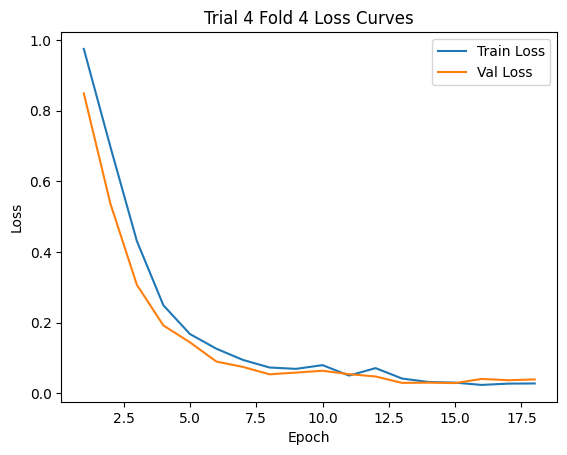

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 5, Epoch 1, Train Loss: 0.9848, Val Loss: 0.8506, Per-label F1: [0.432 0.452 0.644 0.503]
Fold 5, Epoch 2, Train Loss: 0.7214, Val Loss: 0.5492, Per-label F1: [0.632 0.585 0.719 0.733]
Fold 5, Epoch 3, Train Loss: 0.3983, Val Loss: 0.2684, Per-label F1: [0.856 0.79  0.801 0.826]
Fold 5, Epoch 4, Train Loss: 0.2568, Val Loss: 0.1879, Per-label F1: [0.931 0.933 0.887 0.825]
Fold 5, Epoch 5, Train Loss: 0.1505, Val Loss: 0.1233, Per-label F1: [0.953 0.973 0.903 0.879]
Fold 5, Epoch 6, Train Loss: 0.1124, Val Loss: 0.0992, Per-label F1: [0.96  0.948 0.955 0.95 ]
Fold 5, Epoch 7, Train Loss: 0.0871, Val Loss: 0.0905, Per-label F1: [0.939 0.973 0.94  0.973]
Fold 5, Epoch 8, Train Loss: 0.0935, Val Loss: 0.0664, Per-label F1: [0.974 0.967 0.941 0.966]
Fold 5, Epoch 9, Train Loss: 0.0672, Val Loss: 0.0712, Per-label F1: [0.965 0.979 0.955 0.984]
Fold 5, Epoch 10, Train Loss: 0.0543, Val Loss: 0.0467, Per-label F1: [0.981 0.973 0.964 0.981]
Fold 5, Epoch 11, Train Loss: 0.0448, Val Loss: 0

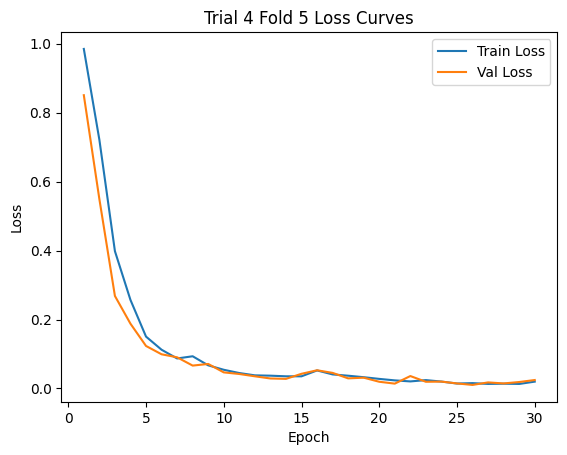

Trial 4 Mean F1: 0.9907

Trial 5, Params: {'batch_size': 64, 'lr': 0.0005, 'lstm_hidden': 64, 'tabular_hidden': 16, 'combined_hidden': 64, 'dropout': 0.1, 'bidirectional': True}


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 1, Epoch 1, Train Loss: 1.0288, Val Loss: 0.9258, Per-label F1: [0.454 0.488 0.626 0.402]
Fold 1, Epoch 2, Train Loss: 0.8323, Val Loss: 0.7424, Per-label F1: [0.504 0.524 0.758 0.597]
Fold 1, Epoch 3, Train Loss: 0.6234, Val Loss: 0.4936, Per-label F1: [0.658 0.71  0.821 0.842]
Fold 1, Epoch 4, Train Loss: 0.4450, Val Loss: 0.3499, Per-label F1: [0.751 0.776 0.853 0.869]
Fold 1, Epoch 5, Train Loss: 0.3243, Val Loss: 0.2631, Per-label F1: [0.799 0.818 0.863 0.906]
Fold 1, Epoch 6, Train Loss: 0.2484, Val Loss: 0.2023, Per-label F1: [0.825 0.88  0.89  0.945]
Fold 1, Epoch 7, Train Loss: 0.1911, Val Loss: 0.1523, Per-label F1: [0.834 0.927 0.948 0.973]
Fold 1, Epoch 8, Train Loss: 0.1465, Val Loss: 0.1222, Per-label F1: [0.928 0.954 0.983 0.97 ]
Fold 1, Epoch 9, Train Loss: 0.1150, Val Loss: 0.0960, Per-label F1: [0.942 0.957 0.988 0.976]
Fold 1, Epoch 10, Train Loss: 0.0854, Val Loss: 0.0751, Per-label F1: [0.962 0.967 0.988 0.985]
Fold 1, Epoch 11, Train Loss: 0.0758, Val Loss: 0

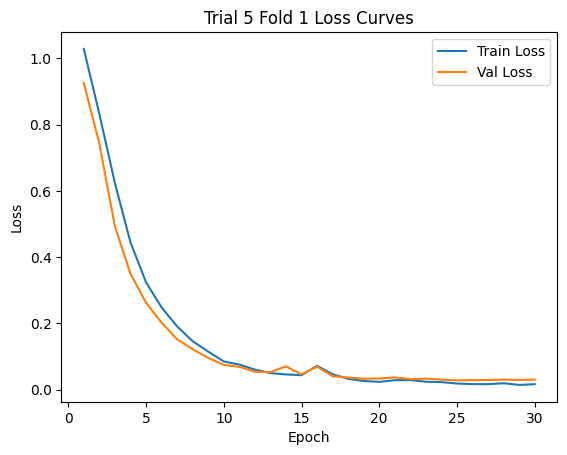

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 2, Epoch 1, Train Loss: 1.0317, Val Loss: 0.9394, Per-label F1: [0.509 0.073 0.613 0.521]
Fold 2, Epoch 2, Train Loss: 0.8188, Val Loss: 0.6404, Per-label F1: [0.72  0.634 0.682 0.746]
Fold 2, Epoch 3, Train Loss: 0.5149, Val Loss: 0.3433, Per-label F1: [0.817 0.786 0.844 0.898]
Fold 2, Epoch 4, Train Loss: 0.3274, Val Loss: 0.2797, Per-label F1: [0.856 0.793 0.943 0.96 ]
Fold 2, Epoch 5, Train Loss: 0.2842, Val Loss: 0.2063, Per-label F1: [0.848 0.881 0.879 0.875]
Fold 2, Epoch 6, Train Loss: 0.2027, Val Loss: 0.1534, Per-label F1: [0.904 0.883 0.953 0.962]
Fold 2, Epoch 7, Train Loss: 0.1459, Val Loss: 0.1118, Per-label F1: [0.906 0.916 0.965 0.971]
Fold 2, Epoch 8, Train Loss: 0.1107, Val Loss: 0.0862, Per-label F1: [0.952 0.936 0.982 0.991]
Fold 2, Epoch 9, Train Loss: 0.0935, Val Loss: 0.0782, Per-label F1: [0.979 0.94  0.973 0.973]
Fold 2, Epoch 10, Train Loss: 0.0764, Val Loss: 0.0585, Per-label F1: [0.979 0.967 0.982 0.985]
Fold 2, Epoch 11, Train Loss: 0.0585, Val Loss: 0

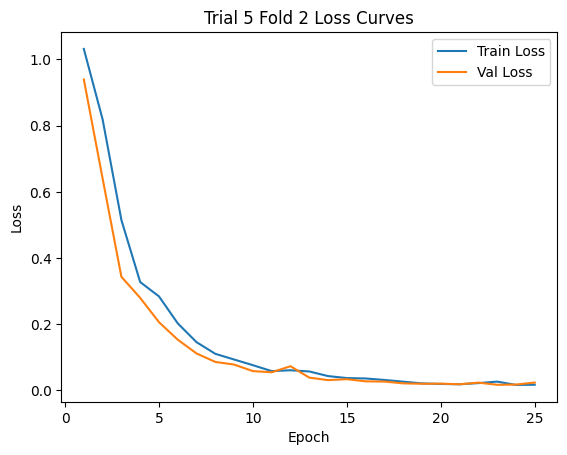

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 3, Epoch 1, Train Loss: 1.0398, Val Loss: 0.9438, Per-label F1: [0.318 0.444 0.64  0.419]
Fold 3, Epoch 2, Train Loss: 0.8606, Val Loss: 0.7825, Per-label F1: [0.339 0.532 0.783 0.667]
Fold 3, Epoch 3, Train Loss: 0.6724, Val Loss: 0.5316, Per-label F1: [0.635 0.609 0.833 0.749]
Fold 3, Epoch 4, Train Loss: 0.4088, Val Loss: 0.3057, Per-label F1: [0.75  0.772 0.923 0.941]
Fold 3, Epoch 5, Train Loss: 0.2682, Val Loss: 0.2277, Per-label F1: [0.81  0.858 0.9   0.931]
Fold 3, Epoch 6, Train Loss: 0.1848, Val Loss: 0.1598, Per-label F1: [0.893 0.918 0.952 0.969]
Fold 3, Epoch 7, Train Loss: 0.1291, Val Loss: 0.1099, Per-label F1: [0.971 0.942 0.95  0.98 ]
Fold 3, Epoch 8, Train Loss: 0.0961, Val Loss: 0.0823, Per-label F1: [0.935 0.98  0.968 0.98 ]
Fold 3, Epoch 9, Train Loss: 0.0787, Val Loss: 0.0637, Per-label F1: [0.963 0.986 0.976 0.992]
Fold 3, Epoch 10, Train Loss: 0.0682, Val Loss: 0.0805, Per-label F1: [0.974 0.962 0.979 0.975]
Fold 3, Epoch 11, Train Loss: 0.0588, Val Loss: 0

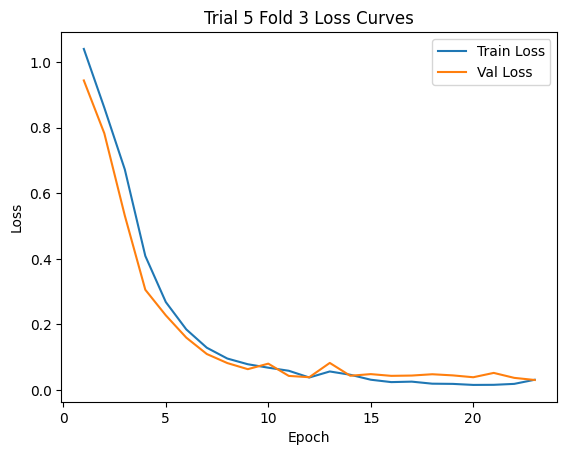

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 4, Epoch 1, Train Loss: 1.0214, Val Loss: 0.9393, Per-label F1: [0.534 0.42  0.632 0.485]
Fold 4, Epoch 2, Train Loss: 0.8462, Val Loss: 0.7645, Per-label F1: [0.536 0.502 0.847 0.674]
Fold 4, Epoch 3, Train Loss: 0.6499, Val Loss: 0.5193, Per-label F1: [0.71  0.66  0.923 0.851]
Fold 4, Epoch 4, Train Loss: 0.3831, Val Loss: 0.2898, Per-label F1: [0.859 0.754 0.958 0.925]
Fold 4, Epoch 5, Train Loss: 0.2231, Val Loss: 0.1679, Per-label F1: [0.905 0.896 0.976 0.984]
Fold 4, Epoch 6, Train Loss: 0.1291, Val Loss: 0.1022, Per-label F1: [0.926 0.958 0.986 0.997]
Fold 4, Epoch 7, Train Loss: 0.0928, Val Loss: 0.0762, Per-label F1: [0.963 0.989 0.983 0.992]
Fold 4, Epoch 8, Train Loss: 0.0805, Val Loss: 0.0775, Per-label F1: [0.954 0.977 0.984 0.99 ]
Fold 4, Epoch 9, Train Loss: 0.0667, Val Loss: 0.0469, Per-label F1: [0.976 0.986 0.993 0.992]
Fold 4, Epoch 10, Train Loss: 0.0529, Val Loss: 0.0441, Per-label F1: [0.966 0.989 0.988 0.995]
Fold 4, Epoch 11, Train Loss: 0.0443, Val Loss: 0

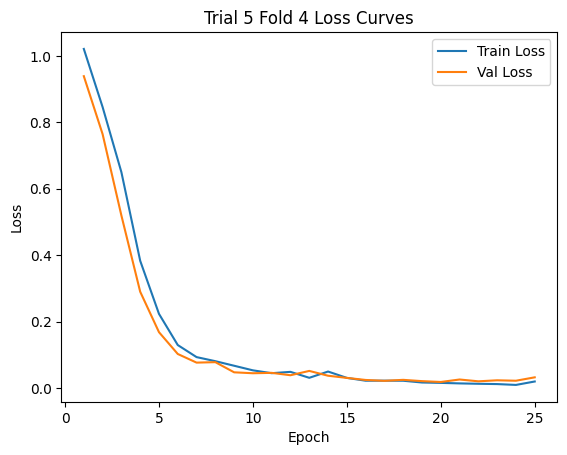

C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Fold 5, Epoch 1, Train Loss: 1.0402, Val Loss: 0.9392, Per-label F1: [0.45  0.474 0.506 0.505]
Fold 5, Epoch 2, Train Loss: 0.8610, Val Loss: 0.7654, Per-label F1: [0.438 0.409 0.65  0.692]
Fold 5, Epoch 3, Train Loss: 0.6657, Val Loss: 0.5628, Per-label F1: [0.692 0.75  0.737 0.794]
Fold 5, Epoch 4, Train Loss: 0.4461, Val Loss: 0.3573, Per-label F1: [0.774 0.74  0.783 0.831]
Fold 5, Epoch 5, Train Loss: 0.2804, Val Loss: 0.2307, Per-label F1: [0.847 0.898 0.801 0.841]
Fold 5, Epoch 6, Train Loss: 0.1832, Val Loss: 0.1603, Per-label F1: [0.922 0.921 0.842 0.867]
Fold 5, Epoch 7, Train Loss: 0.1290, Val Loss: 0.1121, Per-label F1: [0.966 0.956 0.907 0.931]
Fold 5, Epoch 8, Train Loss: 0.0934, Val Loss: 0.0951, Per-label F1: [0.968 0.982 0.949 0.955]
Fold 5, Epoch 9, Train Loss: 0.0880, Val Loss: 0.0655, Per-label F1: [0.978 0.988 0.972 0.987]
Fold 5, Epoch 10, Train Loss: 0.0573, Val Loss: 0.0503, Per-label F1: [0.981 0.988 0.979 0.997]
Fold 5, Epoch 11, Train Loss: 0.0712, Val Loss: 0

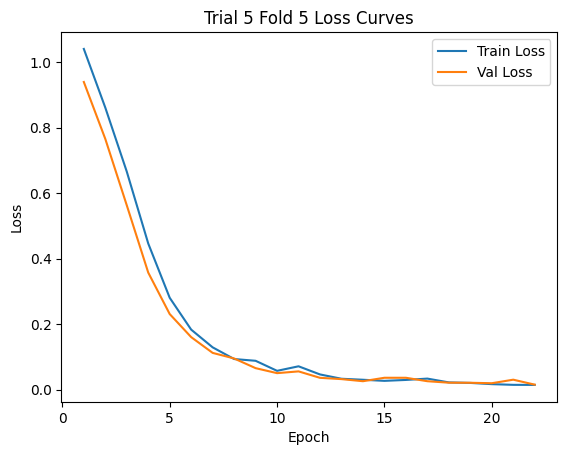

Trial 5 Mean F1: 0.9929

Best Mean F1: 0.9948465667310591
Best Hyperparameters: {'batch_size': 32, 'lr': 0.001, 'lstm_hidden': 32, 'tabular_hidden': 16, 'combined_hidden': 64, 'dropout': 0.1, 'bidirectional': True}


In [29]:
sensor_data = X_train_sensor_clipped
tab_data = X_train_tab_scaled
#labels = y_train_multi_df
labels = y_train_multi_df.values.astype(np.float32)

best_params, best_f1, best_model_state = run_random_search_cv(
    sensor_data=sensor_data,
    tab_data=tab_data,
    labels=labels,
    num_trials=5,
    num_epochs=30,
    patience=5,
    device=device
)


In [15]:
import torch
import pickle
from sklearn.metrics import f1_score, accuracy_score, precision_score

# Load best hyperparameters
with open("best_hyperparams.pkl", "rb") as f:
    best_params = pickle.load(f)
print("Best Hyperparameters:", best_params)

# Load best model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = BrakeLSTMModel(
    X_train_tab_scaled.shape[1],
    best_params["lstm_hidden"],
    best_params["tabular_hidden"],
    best_params["combined_hidden"]
).to(device)

model.load_state_dict(torch.load("Multi_label_classweight_LSTM.pth"))
model.eval()


Best Hyperparameters: {'batch_size': 32, 'lr': 0.001, 'lstm_hidden': 32, 'tabular_hidden': 16, 'combined_hidden': 64, 'dropout': 0.1, 'bidirectional': True}


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


BrakeLSTMModel(
  (lstm): LSTM(6, 32, batch_first=True, dropout=0.3, bidirectional=True)
  (tab_fc): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=80, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (fc_out): Linear(in_features=64, out_features=4, bias=True)
)

In [16]:
test_dataset = BrakeDataset(
    X_test_sensor_clipped,
    X_test_tab_scaled,
    y_test_multi_df.values.astype(np.float32)  # ✅ Fix
)
from torch.utils.data import DataLoader

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

sensor, tab, label = next(iter(test_loader))
print(sensor.shape, tab.shape, label.shape)


torch.Size([64, 128, 6]) torch.Size([64, 3]) torch.Size([64, 4])



=== Evaluation on Test Data ===
Test Loss: 1.4780
Macro F1-score: 0.1600
Micro F1-score: 0.1845
Macro Precision: 0.1286
Micro Precision: 0.1430
Exact Match Ratio (subset accuracy): 0.3656
Hamming Loss: 0.2340

=== Per-label Classification Report ===
              precision    recall  f1-score   support

  front_left       0.02      0.02      0.02       103
 front_right       0.13      0.14      0.13        96
   rear_left       0.20      0.26      0.23       104
  rear_right       0.17      0.61      0.26       105

   micro avg       0.14      0.26      0.18       408
   macro avg       0.13      0.26      0.16       408
weighted avg       0.13      0.26      0.16       408
 samples avg       0.09      0.11      0.09       408

Accuracy for front_left: 0.7762
Accuracy for front_right: 0.8282
Accuracy for rear_left: 0.8172
Accuracy for rear_right: 0.6424


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

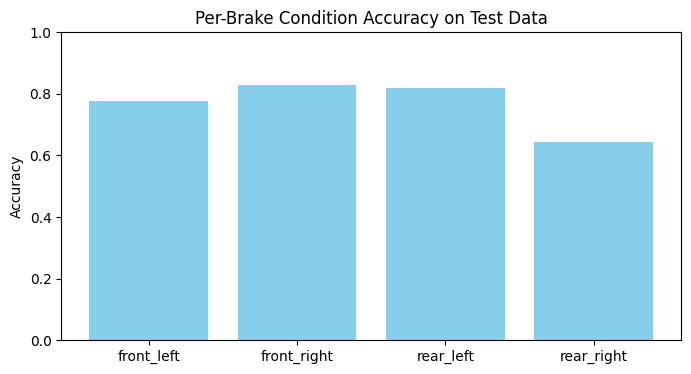

front_left AUC: 0.3463
front_right AUC: 0.6187
rear_left AUC: 0.7216
rear_right AUC: 0.6660


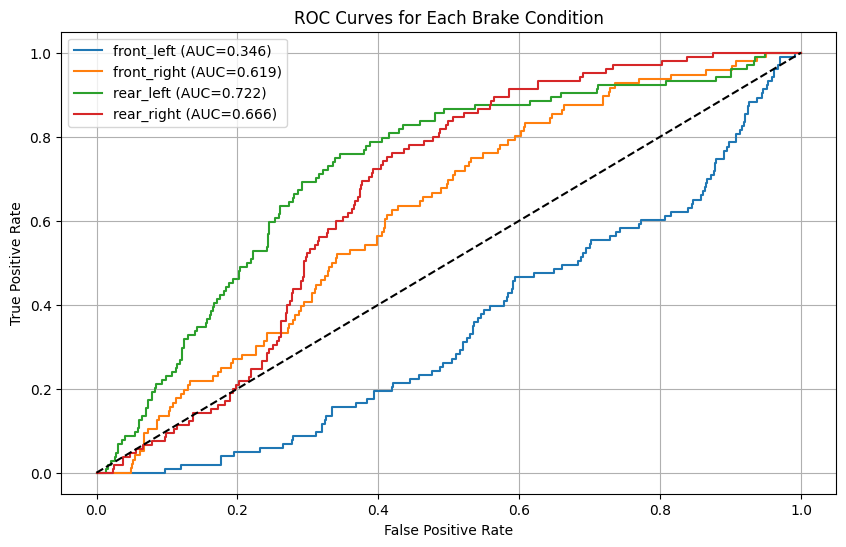

In [33]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, classification_report, hamming_loss
import numpy as np
import torch

# Evaluate model on test data
all_preds, all_labels = [], []
criterion = torch.nn.BCEWithLogitsLoss()

model.eval()
test_loss = 0

with torch.no_grad():
    for sensor, tab, label in test_loader:
        sensor, tab, label = sensor.to(device), tab.to(device), label.to(device)
        outputs = model(sensor, tab)
        loss = criterion(outputs, label)
        test_loss += loss.item() * sensor.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(label.cpu().numpy())

# Aggregate predictions and labels
test_loss /= len(test_loader.dataset)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# Calculate metrics
f1_macro = f1_score(all_labels, all_preds, average="macro")
f1_micro = f1_score(all_labels, all_preds, average="micro")
precision_macro = precision_score(all_labels, all_preds, average="macro")
precision_micro = precision_score(all_labels, all_preds, average="micro")
# Subset accuracy (exact match ratio)
exact_match_acc = np.mean(np.all(all_preds == all_labels, axis=1))
# Hamming loss
hamming = hamming_loss(all_labels, all_preds)

print(f"\n=== Evaluation on Test Data ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Macro F1-score: {f1_macro:.4f}")
print(f"Micro F1-score: {f1_micro:.4f}")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Micro Precision: {precision_micro:.4f}")
print(f"Exact Match Ratio (subset accuracy): {exact_match_acc:.4f}")
print(f"Hamming Loss: {hamming:.4f}")

# Detailed classification report per brake condition
brake_conditions = ["front_left", "front_right", "rear_left", "rear_right"]
print("\n=== Per-label Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=brake_conditions))

# Per-brake accuracy visualization
import matplotlib.pyplot as plt

per_brake_acc = []
for i, brake in enumerate(brake_conditions):
    acc_i = accuracy_score(all_labels[:, i], all_preds[:, i])
    per_brake_acc.append(acc_i)
    print(f"Accuracy for {brake}: {acc_i:.4f}")

plt.figure(figsize=(8, 4))
plt.bar(brake_conditions, per_brake_acc, color='skyblue')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Per-Brake Condition Accuracy on Test Data")
plt.show()

# ROC AUC visualization for each brake
from sklearn.metrics import roc_auc_score, roc_curve

# Get predicted probabilities
all_probs = []
with torch.no_grad():
    for sensor, tab, _ in test_loader:
        sensor, tab = sensor.to(device), tab.to(device)
        outputs = torch.sigmoid(model(sensor, tab)).cpu().numpy()
        all_probs.append(outputs)
all_probs = np.vstack(all_probs)

# Plot ROC curves
plt.figure(figsize=(10, 6))
for i, brake in enumerate(brake_conditions):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    auc = roc_auc_score(all_labels[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"{brake} (AUC={auc:.3f})")
    print(f"{brake} AUC: {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Each Brake Condition")
plt.legend()
plt.grid()
plt.show()


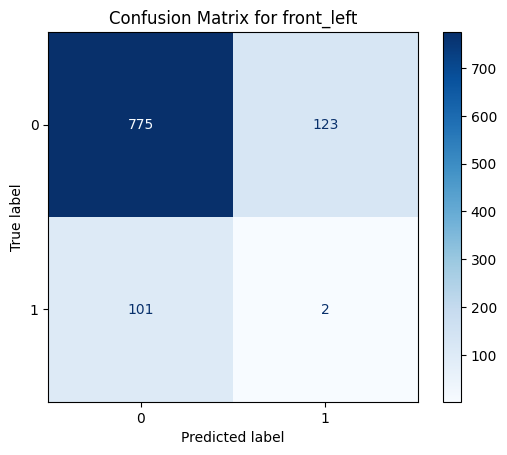

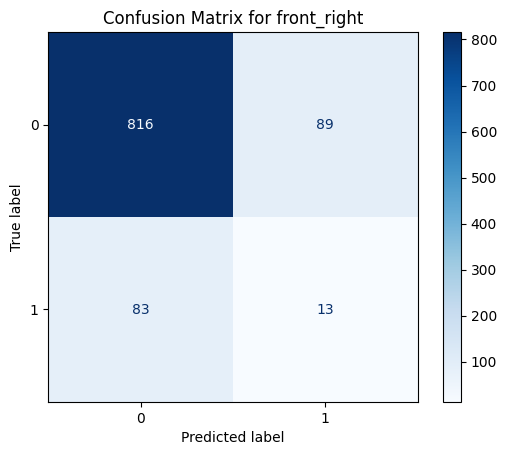

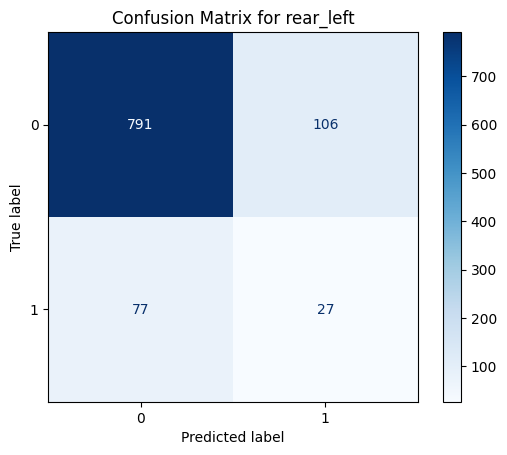

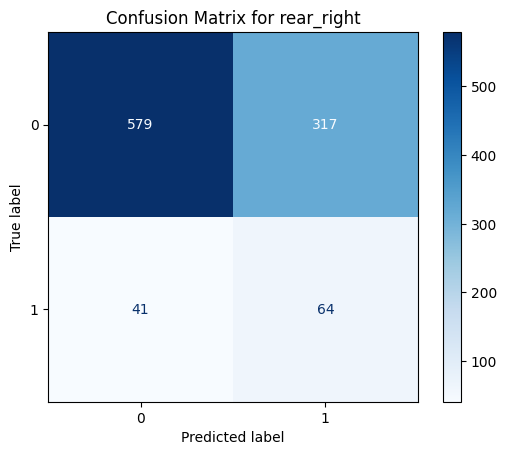

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# brake_conditions defined earlier
# all_labels and all_preds are numpy arrays with shape (num_samples, 4)

for i, brake in enumerate(brake_conditions):
    cm = confusion_matrix(all_labels[:, i], all_preds[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues, values_format="d")
    plt.title(f"Confusion Matrix for {brake}")
    plt.show()
